# Fixed Effects and Bootstrapping
### BU DX702 — Experimental Design and Causality

**Recurring question:** Does GenAI use affect exam performance?

All data are simulated for teaching. The "true effect" below is a known benchmark that lets us
check our methods — it is **not** an empirical claim about GenAI.

## 0. Setup

## Cell 1 — Set up libraries and the simulation truth

### Why are we doing this?

This notebook is a controlled simulation: the data are generated from known rules, so we can check whether each estimator recovers the planted truth. Before any data exist, we load the tools and define the "answer sheet" constants.

### What are we doing?

We import numpy, pandas, statsmodels, matplotlib, and scipy's logistic function; fix the plotting style; and define the true parameters (`TRUE_EFFECT = -5.0`, `TRUE_INTERCEPT = 70.0`, `TRUE_PREP_SLOPE = 4.0`), the preparation-mode values, the noise level, the band cutoffs/labels, and the shared random generator.

### How does it work?

- `expit` is the logistic function used when GenAI adoption probability depends on preparedness or school quality.
- `TRUE_EFFECT = -5.0` is the causal effect of GenAI on exam score that every estimator is trying to recover. The comment stresses it is "instructor-only": the analyst in the story never sees it.
- `PREP_MODES = [2, 5, 8]` are the centers of three preparedness populations; `BAND_BINS` and `BAND_LABELS` convert continuous preparedness into the coarse Beginner/Intermediate/Advanced bands.
- `rng = np.random.default_rng(42)` fixes the seed so every run produces identical data.

### Why did we choose this approach?

Global constants keep the notebook reproducible and let every later cell print "(true: -5.0)" for comparison. The separation between hidden truth and analyst-visible data is the pedagogical engine of the whole notebook.

### Alternatives

- Real data would avoid simulation, but then we would not know the true effect and could not grade our estimators.
- Defining constants inside each cell would duplicate code and risk drift; one setup cell is DRY.

### Key Data Science Concepts

- **Data-generating process (DGP)**: the rules that create the data.
- **Ground truth / benchmark**: a known target used to validate methods.
- **Reproducibility**: a fixed seed means identical runs.

### Potential Issues / Improvements

- If the seed changes, every number in the notebook changes — that is expected, but results only match this notebook for seed 42.
- The band cutoffs (3.5, 6.5) are author choices; different cutoffs change how much confounding the bands absorb.

### What should we expect to examine after execution?

The next cell calls `simulate_school_A`, which uses these constants to generate the first data release — one school, 100 students.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.special import expit

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# --- Simulation truth: instructor-only. The analyst never sees these. ---
TRUE_EFFECT = -5.0        # a  : effect of GenAI use on exam score
TRUE_INTERCEPT = 70.0     # c  : global baseline
TRUE_PREP_SLOPE = 4.0     # b  : effect of one unit of preparedness

PREP_MODES = [2.0, 5.0, 8.0]
PREP_SD = 0.8
NOISE_SD = 3.0

BAND_BINS = [-np.inf, 3.5, 6.5, np.inf]
BAND_LABELS = ["Beginner", "Intermediate", "Advanced"]

rng = np.random.default_rng(42)

---
## 1. Bridge from what we already know

Earlier sessions established: if preparedness $Z_i$ affects **both** GenAI use $X_i$ and exam score $Y_i$,
then leaving $Z_i$ out biases our estimate of the GenAI effect.

$$Y_i = c + aX_i + bZ_i + \epsilon_i$$

- $Y_i$ — exam score for student $i$
- $X_i$ — 1 if the student uses GenAI, 0 otherwise
- $Z_i$ — preparedness
- $a$ — the **true treatment effect** we want; $\hat a$ denotes our sample estimate

Today we push on two harder questions:

1. What if we cannot observe preparedness at all — only a **coarse band**?
2. What if our data come from **many schools** that differ in ways we never measured?

---
## 2. The district's first data release

> A district is reviewing its GenAI policy. Exam scores look lower for GenAI users, but the district
> wants to know whether GenAI is *responsible*. Exam records and placement assessments live in separate
> systems, so linking them takes staff time. An initial release covers **one school, 100 students**.
> Under the data-sharing agreement, exact placement scores are replaced with **preparation bands** —
> Beginner, Intermediate, Advanced.

**Hold these questions in mind:**
- Can we estimate GenAI's effect using only bands?
- What student differences survive *inside* a band?
- How confident can we be from 100 records?

### What the analyst can and cannot see

| Symbol | Meaning | Visible to analyst? |
|--------|---------|---------------------|
| $a = -5$ | True GenAI effect | **No** |
| $b = 4$ | True preparedness slope | **No** |
| $Z_i$ | Exact preparedness score | **No** |
| $g_i$ | Preparation band | Yes |
| $X_i$ | GenAI use | Yes |
| $Y_i$ | Exam score | Yes |

**Confounding in School A:** more-prepared students are *less* likely to use GenAI and *also* score
higher. Both channels push the naive comparison in the same wrong direction.

## Cell 2 — Simulate School A and preview what the analyst receives

### Why are we doing this?

We create the first dataset. School A exhibits *individual-level* confounding: more-prepared students are less likely to use GenAI and score higher on exams, so a naive comparison of users vs. non-users is contaminated.

### What are we doing?

We define `simulate_school_A(n, rng)`, which returns a DataFrame with `prep`, `genai`, `band`, and `score`. We keep the full object (`school_A_full`, which contains the secret `prep` column) and hand the analyst only `df_A` with `genai`, `band`, and `score`. Then we print the first six rows.

### How does it work?

- `prep = rng.choice(PREP_MODES, size=n) + rng.normal(0, PREP_SD, size=n)`: each student's preparedness is a mode plus noise.
- `p_genai = expit(-0.8 * (prep - 5.0))`: more prepared → smaller probability of GenAI use.
- `genai = rng.binomial(1, p_genai)` draws the binary usage flag.
- `score = 70 + (-5)*genai + 4*prep + noise`: the true equation. GenAI *reduces* the score by 5; preparedness raises it by 4 per unit. This is the hidden truth.
- `band = pd.cut(prep, bins=BAND_BINS, labels=BAND_LABELS)` buckets preparedness into bands.

### Why did we choose this approach?

The invisible `prep` column is the whole point. The analyst must estimate the effect with a confounder they cannot see — exactly the situation real studies face when a key variable is unmeasured.

### Alternatives

- Releasing exact preparedness would let a simple regression do the job (we saw that in earlier weeks).
- Simulating different confounding strengths would show how the naive gap grows with confounding.

### Key Data Science Concepts

- **Observed vs. unobserved variables**: only some variables enter the dataset.
- **Individual-level confounding**: the confounder varies within every group.
- **Data release / measurement constraints**: what the analyst receives is a modeling decision.

### Potential Issues / Improvements

- The printed rows are a preview, not a summary; means and gaps come later.
- The order of rows is random, so reading them one by one tells us little.

### What should we expect to examine after execution?

This cell prints the first six rows of the analyst's data. After execution we will look at treatment, band, and score values side by side.


In [2]:
def simulate_school_A(n, rng):
    """School A: preparedness confounds GenAI use at the INDIVIDUAL level."""
    prep = rng.choice(PREP_MODES, size=n) + rng.normal(0, PREP_SD, size=n)
    p_genai = expit(-0.8 * (prep - 5.0))          # more prepared -> less GenAI
    genai = rng.binomial(1, p_genai)
    score = (TRUE_INTERCEPT
             + TRUE_EFFECT * genai
             + TRUE_PREP_SLOPE * prep
             + rng.normal(0, NOISE_SD, size=n))
    band = pd.cut(prep, bins=BAND_BINS, labels=BAND_LABELS)
    return pd.DataFrame({"prep": prep, "genai": genai, "band": band, "score": score})


school_A_full = simulate_school_A(100, rng)          # instructor object (has `prep`)
df_A = school_A_full[["genai", "band", "score"]]      # what the analyst receives

print(f"School A — {len(df_A)} students released")
print(df_A.head(6).to_string(index=False))

School A — 100 students released
 genai         band     score
     1     Beginner 74.889736
     0     Advanced 96.943068
     0 Intermediate 86.524046
     0 Intermediate 98.407864
     1 Intermediate 76.474834
     0     Advanced 97.686695


## Result Interpretation — Cell 2

### What did we actually get?

The head shows six rows of GenAI users and non-users spread across the Beginner, Intermediate, and Advanced bands, with scores ranging from about 75 to 98.

### What does this result mean?

Six rows are too few to estimate anything, but we can see that band and score move together — higher bands show higher scores. That co-movement foreshadows the confound between preparedness (which drives both GenAI use and exam scores) and the outcome.

### How should I interpret the numbers?

No statistics are printed; we are reading raw rows. Scores around 75–98 reflect the 70 baseline plus preparedness (≈ 8–32 points via the 4-point slope) plus the GenAI effect and noise. The useful signal is the visible band–score relationship, not any single value.

### What does this tell us?

The data object `df_A` is exactly what a real analyst would hold: treatment, a coarse confounder proxy, and outcome — but not the exact confounder.

### What can we conclude?

We can already see bands and scores co-move in the preview; nothing more.

### What can we NOT conclude?

Nothing about the GenAI effect yet — that requires the comparisons in the next cells.

### Why does this result matter?

It sets up the analyst's handicap: the exact confounder (preparedness) is hidden, so the analysis must work with the coarse band labels only.

### What should we do next?

The next cell computes the unadjusted score gap between GenAI users and non-users and plots it — the naive comparison that ignores bands entirely.


### A first look: the unadjusted gap

## Cell 3 — Compute the unadjusted gap and visualize it

### Why are we doing this?

The district's first instinct is to compare average exam scores of GenAI users vs. non-users. This cell produces that naive comparison and makes it visual, so we can later contrast it with the controlled estimates.

### What are we doing?

We group the 100 students by `genai`, compute the mean `score` in each group, print both means and their difference, and draw a two-bar chart.

### How does it work?

- `df_A.groupby("genai")["score"].mean()` gives one mean per group; `means[0]` is No GenAI, `means[1]` is GenAI.
- `means[1] - means[0]` is the raw gap (GenAI minus No GenAI).
- The bar chart colors the groups and labels each bar with its value; the y-axis is fixed (55–95) so the visual gap is not exaggerated.

### Why did we choose this approach?

A two-number summary plus a bar chart is the clearest way to state the naive claim before any modeling.

### Alternatives

- A t-test would add a p-value, but significance is not the issue here — *bias* is. After execution we will read the size of the gap between the two group means.
- Box plots or histograms would show score distributions instead of just means.

### Key Data Science Concepts

- **Raw mean difference**: the simple comparison of group averages.
- **Selection/confounding**: the groups differ in preparedness, so the raw difference mixes several causes.

### Potential Issues / Improvements

- The comparison ignores bands and preparedness entirely, which is exactly why the raw gap may be biased — that is the point of the exercise.
- n = 100 is small; the two group means (and the gap) would shift with a different sample or seed.
- The y-axis is fixed for a fair visual comparison, so small differences can look flatter than they are on the bars.

### What should we expect to examine after execution?

This cell prints the group means and the raw gap, and draws a bar chart. After execution we will read the gap between GenAI users and non-users.


Mean score — No GenAI: 97.0   GenAI: 78.9
Raw gap (GenAI − No GenAI): -18.1


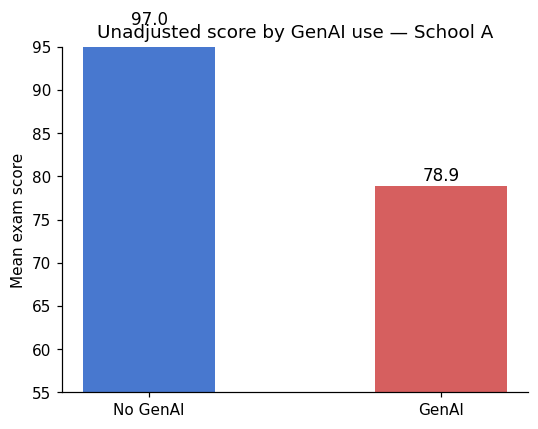

In [3]:
means = df_A.groupby("genai")["score"].mean()
print(f"Mean score — No GenAI: {means[0]:.1f}   GenAI: {means[1]:.1f}")
print(f"Raw gap (GenAI − No GenAI): {means[1] - means[0]:+.1f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No GenAI", "GenAI"], [means[0], means[1]], color=["#4878CF", "#D65F5F"], width=0.45)
for i, v in enumerate([means[0], means[1]]):
    ax.text(i, v + 0.6, f"{v:.1f}", ha="center", fontsize=11)
ax.set_ylabel("Mean exam score")
ax.set_title("Unadjusted score by GenAI use — School A")
ax.set_ylim(55, 95)
plt.tight_layout()
plt.show()

## Result Interpretation — Cell 3

### What did we actually get?

Mean score — No GenAI: 97.0; GenAI: 78.9; raw gap **(GenAI − No GenAI): −18.1** points.

### What does this result mean?

GenAI users score, on average, 18 points lower than non-users. Because the true effect is −5, the naive gap is about 3.6× too large.

### How should I interpret the numbers?

Gap units are exam points. The reference point is the true effect, −5.0. Both confounding channels push the same way: prepared students avoid GenAI *and* score higher, so the non-user group is lifted for non-treatment reasons.

### What does this tell us?

The data really do show users scoring far below non-users — but that gap is not (yet) evidence about GenAI's causal effect.

### What can we conclude?

The comparison is descriptive. If we naively believed it, we would overstate GenAI's harm by a factor of ~3.6.

### What can we NOT conclude?

We cannot attribute the −18.1 to GenAI itself; preparedness has not been accounted for. The bar chart proves nothing about causation.

### Why does this result matter?

This is the naive baseline that every controlled method in the rest of the notebook is trying to correct.

### What should we do next?

Discussion 1 asks "who is in each group?"; the next cell formalizes this same naive gap as a pooled regression coefficient, making the omitted-variable structure explicit.


**Discussion 1.** The gap suggests GenAI is causes a significant imapct on exam scores. Before we believe it — *who* is in each group?
What would you need to know to interpret this as GenAI's effect?

---
## 3. Pooled regression: the same mistake, formalised

## Cell 4 — Pooled regression: the naive gap, formalized

### Why are we doing this?

We convert the −18.1 group comparison into a regression. A 0/1 treatment makes the regression coefficient exactly the mean difference, so this is the same number in model form — and now we can start controlling variables.

### What are we doing?

We fit `score ~ genai + constant` over all 100 students (pooled, ignoring bands) with statsmodels OLS and print the GenAI coefficient.

### How does it work?

- `sm.add_constant(df_A["genai"])` adds a column of ones for the intercept.
- `sm.OLS(score, X).fit()` estimates the intercept and the GenAI slope by least squares.
- With a binary regressor, the OLS slope equals the difference between group means — identical to the −18.1 from the previous cell.

### Why did we choose this approach?

Regression is the formal language the rest of the notebook uses. Showing the naive number as a coefficient lets us later compare coefficients across models (pooled vs. band FE vs. school FE) on a common scale.

### Alternatives

- An ANOVA or t-test would formalize the same comparison but would not extend to the fixed-effects models that follow.

### Key Data Science Concepts

- **Dummy-variable regression**: a 0/1 predictor's coefficient is a mean difference.
- **Omitted-variable bias**: the model is misspecified, not miscalculated — preparedness is simply absent.

### Potential Issues / Improvements

- The model omits preparedness on purpose, so the coefficient is structurally biased — more data would not fix it.
- Only 100 students are used, so the estimate also carries sampling noise on top of the bias.
- The binary regressor encodes "users vs. non-users", so any within-group heterogeneity is averaged away.

### What should we expect to examine after execution?

This cell prints the pooled OLS coefficient. After execution we will compare it with the group-mean gap from the previous cell and with the true effect.


In [4]:
m_pooled_A = sm.OLS(df_A["score"], sm.add_constant(df_A["genai"])).fit()
print(f"Pooled OLS — GenAI coefficient: {m_pooled_A.params['genai']:+.2f}   (true: {TRUE_EFFECT:+.1f})")

Pooled OLS — GenAI coefficient: -18.08   (true: -5.0)


## Result Interpretation — Cell 4

### What did we actually get?

The pooled OLS coefficient on `genai` is **−18.08** (true effect: −5.0).

### What does this result mean?

The regression faithfully reports the *association* between GenAI and score while ignoring preparedness. The printed note is precise: "Roughly three-and-a-half times too large. Regression did nothing wrong — we simply asked it a question that omits preparedness."

### How should I interpret the numbers?

The coefficient is in exam points per unit of GenAI use. −18.08 vs. the true −5.0 is about 3.6× too large. Because the regressor is binary, the OLS slope equals the group-mean difference — which is why it matches the previous cell's −18.1.

### What does this tell us?

The naive regression faithfully reports the association; the problem is the question it was asked, not the arithmetic.

### What can we conclude?

Ignoring preparedness yields a coefficient far from the truth. The estimate would still be precisely estimated ("significant") because the bias is structural.

### What can we NOT conclude?

We cannot say GenAI lowers scores by ~18 points. The bias would persist even with more data.

### Why does this result matter?

It converts the descriptive gap into a model coefficient, which becomes the common scale for comparing every later estimator in the notebook.

### What should we do next?

The markdown after this cell asks whether the available **bands** can rescue the estimate; the next section tests that with band fixed effects.


Roughly three-and-a-half times too large. Regression did nothing wrong — we simply asked it a
question that omits preparedness, and preparedness is not available to us.

But the **bands** are available. Can they rescue us?

---
## 4. Preparation-band fixed effects

**Idea:** give every band its own intercept, then compare users to non-users *within the same band*.

$$Y_i = aX_i + \alpha_{\text{Beg}}D^{\text{Beg}}_i + \alpha_{\text{Int}}D^{\text{Int}}_i + \alpha_{\text{Adv}}D^{\text{Adv}}_i + \epsilon_i$$

where $D^g_i = 1$ when student $i$ is in band $g$ and $0$ otherwise, and $\alpha_g$ is that band's
baseline score. There is **no separate intercept** — each dummy *is* its group's intercept.

### Approach 1 — indicator variables

Here is the design matrix the regression actually sees:

## Cell 5 — Build the band-indicator design matrix
### Why are we doing this?
Fixed effects need one dummy column per group, and we want to see exactly what the regression's design matrix looks like before fitting. This makes the "no separate intercept" convention visible.
### What are we doing?
We turn the `band` column into three 0/1 indicator columns (Beginner, Intermediate, Advanced) with `pd.get_dummies(..., drop_first=False)` and print the first six rows alongside `genai`.
### How does it work?
- `pd.get_dummies(df_A["band"], drop_first=False)` creates one column per band; `.astype(int)` converts booleans to 0/1.
- `pd.concat([df_A[["genai"]], band_dummies], axis=1)` places the treatment next to the indicators.
- Because we do **not** drop the first band, the model will be fit *without* a global intercept — each dummy then *is* its band's intercept.
### Why did we choose this approach?
The markdown equation `Y = aX + α_Beg·D_Beg + α_Int·D_Int + α_Adv·D_Adv + ε` uses exactly this parameterization (no overall intercept), so the design matrix should match the math.
### Alternatives
- `drop_first=True` plus a constant column is equivalent: the dropped band becomes the reference level. The slope on `genai` is identical; only the intercepts' encoding changes.
### Key Data Science Concepts
- **Dummy/indicator coding**: categorical → numeric.
- **Design matrix**: the X the regression actually sees.
- **Reference level / no-intercept parameterization**: equivalent encodings of the same model.
### Potential Issues / Improvements
- Six rows are a preview; the full matrix has 100 rows.
- If any band were empty, `get_dummies` would drop it silently — here all three are present.

### What should we expect to examine after execution?

This cell prints the first rows of the band-indicator design matrix. After execution we will verify the one-hot structure (exactly one band = 1 per row, no intercept column).


In [5]:
band_dummies = pd.get_dummies(df_A["band"], drop_first=False).astype(int)
print(pd.concat([df_A[["genai"]], band_dummies], axis=1).head(6).to_string(index=False))

 genai  Beginner  Intermediate  Advanced
     1         1             0         0
     0         0             0         1
     0         0             1         0
     0         0             1         0
     1         0             1         0
     0         0             0         1


## Result Interpretation — Cell 5

### What did we actually get?

The preview shows six students, each with a `genai` flag (0 or 1) and exactly one of the three band columns set to 1 — the one-hot encoding of Beginner/Intermediate/Advanced — with all three bands present.

### What does this result mean?

This is the exact matrix OLS will see: treatment plus three band indicators, and **no intercept column**, because the three dummies together play the role of the band intercepts.

### How should I interpret the numbers?

The band columns are 0/1; each row has exactly one 1 across them (one-hot). The reference equation is the fixed-effects model `Y = aX + α_Beg·D_Beg + α_Int·D_Int + α_Adv·D_Adv + ε`, where the dummies replace the intercept.

### What does this tell us?

The design encodes the fixed-effects equation from the markdown, so the coefficient fitted in the next cell will measure the within-band effect.

### What can we conclude?

The encoding matches the model we intend to fit; nothing more can be read from a preview.

### What can we NOT conclude?

Six rows are only a preview of 100 — the remaining rows follow the same pattern. And the design matrix alone says nothing about the sign or size of the effect; that requires the fit.

### Why does this result matter?

It makes the "no intercept" fixed-effects convention concrete before any estimation.

### What should we do next?

This exact matrix feeds the next cell, which fits the band-indicator fixed-effects model and prints the GenAI coefficient and one intercept per band.


## Cell 6 — Fit the band-indicator fixed-effects model

### Why are we doing this?

This is the first real fix attempt: give each band its own intercept and compare users vs. non-users *within* the same band. The coefficient on `genai` then measures the within-band association.

### What are we doing?

We combine `genai` with the three band dummies into one `X`, fit OLS *without* a global constant, and print the four estimated coefficients.

### How does it work?

- `sm.OLS(score, X_band)` — note there is no `sm.add_constant`: the three band columns together act as the intercepts.
- `m_band_A.params` returns the GenAI slope and one intercept per band.

### Why did we choose this approach?

The dummies are the direct implementation of the fixed-effects equation from the section's markdown. Each band intercept absorbs the average score of that band, including its typical preparedness.

### Alternatives

- Demeaning (Cell 7) reaches the same slope by algebra instead of dummies — the equivalence is the next teaching point.

### Key Data Science Concepts

- **Fixed effects = group intercepts**: each group gets its own baseline.
- **Nuissance parameters**: the band intercepts are absorbed, not interpreted.

### Potential Issues / Improvements

- The band cutoffs (3.5, 6.5) are arbitrary; different cutoffs would change how much confounding the bands absorb.
- Preparedness still varies inside each band, leaving residual bias that bands cannot remove.
- Small within-band sample sizes make some of the band-level coefficients noisy.

### What should we expect to examine after execution?

This cell prints the fitted coefficients. After execution we will read the GenAI slope and the three band intercepts.


In [6]:
X_band = pd.concat([df_A[["genai"]], band_dummies], axis=1)
m_band_A = sm.OLS(df_A["score"], X_band).fit()
print("Band-indicator model:")
print(m_band_A.params.round(2).to_string())

Band-indicator model:
genai            -7.00
Beginner         79.18
Intermediate     90.73
Advanced        102.22


## Result Interpretation — Cell 6

### What did we actually get?

`genai` coefficient: **−7.00** (the pooled model said −18.08; truth is −5.0). Band intercepts: Beginner 79.18, Intermediate 90.73, Advanced 102.22.

### What does this result mean?

Giving each band its own intercept removes most of the selection bias: the estimate moved from −18.08 to −7.00, much closer to the true −5. The band intercepts climb with preparedness, confirming that bands carry information.

### How should I interpret the numbers?

The slope is in exam points per unit of GenAI use. −7.00 is a large improvement over −18.08 but still about 2 points away from the true −5.0. The intercepts are nuisance baselines for each band — they should not be read as "the preparedness level," since each mixes many band-level factors.

### What does this tell us?

Controlling for bands removes most of the selection bias: the estimate moved from −18.08 to −7.00.

### What can we conclude?

Within a band, GenAI use is associated with about 7 points lower scores — closer to, but still above, the true −5.

### What can we NOT conclude?

The estimate is still biased: preparedness varies *inside* each band, and the band is too coarse to absorb it. The intercepts are not interpretable as preparedness.

### Why does this result matter?

This is the first demonstration that fixed effects reduce — but do not eliminate — confounding from a coarse confounder proxy.

### What should we do next?

Discussion 2 formalizes why the intercepts are not interpretable as preparedness; then the next cell shows an algebraically equivalent route: demeaning.


**Discussion 2.** The model hands us three band intercepts. What do they represent —
and can we read the preparedness level of each band off them?

<details><summary>Discuss first, then expand</summary>

No. Each intercept absorbs **everything** that makes a band different on average: the global
baseline, the band's typical preparedness, and anything else that varies across bands. The analyst
has no equation to decompose one number into those parts. Fixed effects are *nuisance parameters we
absorb*, not quantities we interpret. We care about the slope on $X_i$.

(Instructor check — the truth we happen to know: $70 + 4 \times \text{mode}$ gives 78, 90, 102.
The estimates land right on top of these, but the analyst could never verify that.)
</details>

### Approach 2 — demeaning (the within transformation)

A second route to the same slope, this time by algebra rather than by dummies.

The actual equation is:
$$Y_i = a X_i + \alpha_g + \epsilon_i$$

Because of linearity of expectations:
$$E[Y_i] = a E[X_i] + \alpha_g + E[\epsilon_i]$$


Average the model within band $g$. The intercept $\alpha_g$ is constant inside the group, and
$E[\epsilon_i] = 0$, so by linearity of expectation:

$$\bar Y_g = a\bar X_g + \alpha_g$$

Subtract that from each student's equation:

$$Y_i - \bar Y_g = a\left(X_i - \bar X_g\right) + \left(\epsilon_i - \bar\epsilon_g\right)$$

$$\widetilde Y_i = a\widetilde X_i + \widetilde\epsilon_i$$

The band intercept is **gone**. Note we must demean *both* the outcome and the treatment.

## Cell 7 — Demeaning: the within transformation

### Why are we doing this?

We want to prove that the band-indicator estimate is not magical: an algebraically different route — subtracting each band's mean from every variable — must give the *identical* slope. This is the within transformation, the standard way to compute fixed effects.

### What are we doing?

We copy `df_A`, subtract each student's band-mean score (`score_dm`) and band-mean GenAI (`genai_dm`), regress the demeaned score on the demeaned treatment *without an intercept*, and compare the slope with the indicator model.

### How does it work?

- `df_A.groupby("band", observed=True)["score"].transform("mean")` broadcasts each band's mean back to its rows; subtracting gives the deviation from the group mean.
- `sm.OLS(score_dm, genai_dm)` — fixed effects need **no intercept** after demeaning, because the group constant cancels: `Y − Ȳ = a(X − X̄) + (ε − ε̄)`.
- `np.isclose(...)` checks whether the two slopes match within floating-point tolerance.

### Why did we choose this approach?

Demeaning is the algorithm real software uses at scale (it avoids building huge dummy matrices). Showing the equivalence builds understanding of *why* fixed effects work.

### Alternatives

- The dummy approach of Cell 6 (exactly equivalent).
- `linearmodels` or `pyfixest` bundles fixed effects in one line, but hides the math.

### Key Data Science Concepts

- **Within transformation**: compare each observation to its group mean.
- **Fixed-effects cancellation**: any variable constant within a group disappears from a demeaned regression — that includes confounders we never measured.
- **Identification from within-group variation**: only deviations from group means drive the slope.

### Potential Issues / Improvements

- The code comment says "Deamean" (typo for demean) — harmless.
- Standard errors from the two implementations can differ due to degrees-of-freedom bookkeeping; the slope is the shared object.

### What should we expect to examine after execution?

This cell prints both slopes and an "Identical?" check. After execution we will see whether the indicator and demeaned routes give the same coefficient.


In [7]:
# Deamean 100 students and fit WITHOUT an intercept
dm_A = df_A.copy()
dm_A["score_dm"] = dm_A["score"] - dm_A.groupby("band", observed=True)["score"].transform("mean")
dm_A["genai_dm"] = dm_A["genai"] - dm_A.groupby("band", observed=True)["genai"].transform("mean")
m_dm_A = sm.OLS(dm_A["score_dm"], dm_A["genai_dm"]).fit()

print(f"Indicator model  : {m_band_A.params['genai']:+.4f}")
print(f"Demeaned model   : {m_dm_A.params['genai_dm']:+.4f}")
print(f"Identical?       : {np.isclose(m_band_A.params['genai'], m_dm_A.params['genai_dm'])}")

Indicator model  : -7.0025
Demeaned model   : -7.0025
Identical?       : True


## Result Interpretation — Cell 7

### What did we actually get?

Indicator model: **−7.0025**; Demeaned model: **−7.0025**; "Identical? **True**."

### What does this result mean?

Two very different code paths — dummy indicators vs. subtracting each band's mean — converge on the same slope, confirming that fixed effects are the same estimator either way.

### How should I interpret the numbers?

Both slopes equal −7.0025 to floating-point precision. The reference is the band-FE slope of −7.00 from the previous cell; the difference is rounding.

### What does this tell us?

Indicator and demeaned fixed effects are the same estimator — a useful check when someone offers a "new" fixed-effects implementation.

### What can we conclude?

Band fixed effects, however computed, estimate the GenAI slope at −7.00 for these data.

### What can we NOT conclude?

Equivalence of the two routes does not make −7.00 the truth; it only proves the two computations agree.

### Why does this result matter?

It establishes demeaning as a practical, scalable way to compute fixed effects without building huge dummy matrices.

### What should we do next?

Discussion 3 raises the degenerate case (a band with no treatment variation); the following cell plots the within-band comparisons and compares the pooled, band-FE, and true numbers side by side.


**These are two equivalent ways to estimate the same fixed-effects slope.**

(Their default *standard errors* need not agree — degrees-of-freedom bookkeeping differs between
the two implementations. The slope is the shared object.)

**Discussion 3.** Demeaning runs on *within-group* variation in treatment.
What happens to a band in which **every** student uses GenAI?

<details><summary>Expand</summary>

Then $X_i - \bar X_g = 0$ for every student in it. Their demeaned treatment is exactly zero, so they
contribute nothing to the slope. This is not a bug — it is an honest statement: **a group with no
treatment variation carries no information about the treatment effect.** We will meet this again
with schools.
</details>

### Did band FE fix the problem?

## Cell 8 — Visualize within-band comparisons and compare all estimators

### Why are we doing this?

We want to see fixed effects with our own eyes: within each band, do GenAI users score below non-users? We also print pooled vs. band-FE vs. true effect in one place to summarize where we stand.

### What are we doing?

We draw a 3-panel figure — one panel per band — with each student's score scattered by GenAI use, black diamonds marking the group means, and then print the three headline numbers.

### How does it work?

- `plt.subplots(1, 3, sharey=True)` makes three panels with a shared y-axis so heights are comparable.
- Each panel filters `df_A` to one band, plots both groups with different markers (`o` for non-users, `s` for users), and overlays the group mean as a black diamond.
- The final `print` shows `m_pooled_A.params['genai']` (−18.08), `m_band_A.params['genai']` (−7.00), and `TRUE_EFFECT` (−5.0).

### Why did we choose this approach?

A picture of the within-group comparisons makes "compare users to non-users holding the band fixed" concrete, and the printed line frames the whole story.

### Alternatives

- A single pooled scatter with colored bands; the facets are clearer here.
- A table of means and differences per band.

### Key Data Science Concepts

- **Within-group comparisons**: the diamonds in each panel move together; the user diamond sits below the non-user diamond in every band.
- **Residual confounding**: the dots are spread within each band — that spread still contains preparedness.

### Potential Issues / Improvements

- Each panel has only a fraction of the 100 students, so per-band means are noisy.
- The residual ≈ 2-point miss vs. the truth is systematic, so collecting more students alone would not remove it.
- Shared y-axes make cross-panel level differences (the band intercepts) easy to compare, but hide within-panel spread details.

### What should we expect to examine after execution?

This cell draws three scatter panels and prints the pooled, band-FE, and true-effect numbers. After execution we will see whether users sit below non-users within each band and compare the estimates.


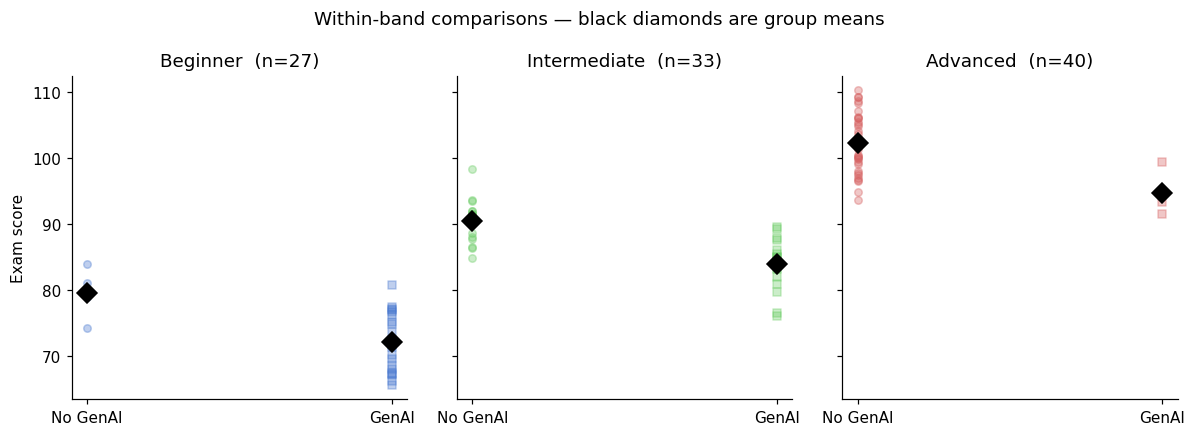

Pooled OLS : -18.08
Band FE    : -7.00
True effect: -5.0


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
band_colors = {"Beginner": "#4878CF", "Intermediate": "#6ACC65", "Advanced": "#D65F5F"}

for ax, band in zip(axes, BAND_LABELS):
    sub = df_A[df_A["band"] == band]
    for g, marker in [(0, "o"), (1, "s")]:
        pts = sub[sub["genai"] == g]["score"]
        ax.scatter([g] * len(pts), pts, alpha=0.35, s=24, color=band_colors[band], marker=marker)
        ax.plot(g, pts.mean(), "D", markersize=9, color="black", zorder=5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No GenAI", "GenAI"])
    ax.set_title(f"{band}  (n={len(sub)})")

axes[0].set_ylabel("Exam score")
fig.suptitle("Within-band comparisons — black diamonds are group means", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Pooled OLS : {m_pooled_A.params['genai']:+.2f}")
print(f"Band FE    : {m_band_A.params['genai']:+.2f}")
print(f"True effect: {TRUE_EFFECT:+.1f}")

## Result Interpretation — Cell 8

### What did we actually get?

Three panels, one per band, show GenAI users below non-users in every band. The printed comparison: pooled OLS −18.08, band FE −7.00, true −5.0.

### What does this result mean?

Band fixed effects removed the *between*-band average difference (the panels sit at different heights) but cannot remove *within*-band preparedness variation: coarse labels are not perfect adjustment.

### How should I interpret the numbers?

Per-band gaps are in exam points and look similar across panels (users below non-users by several points). The reference line is the true −5.0; FE at −7.00 still misses by ≈ 2 points, and the miss is systematic, not noise.

### What does this tell us?

Bands absorb a large chunk of the confounding, but a residual gap of ≈ 2 points vs. the truth remains, and it is systematic, not noise.

### What can we conclude?

Band fixed effects are a big improvement over pooling but still biased on this data.

### What can we NOT conclude?

We cannot claim −7.00 is the causal effect, and we cannot fix the residual bias without a finer grouping or the exact confounder.

### Why does this result matter?

It provides concrete visual evidence that coarse adjustment leaves residual confounding.

### What should we do next?

The markdown explains the residual gap. Next the district releases **30 schools**, introducing group-level confounding — the next cell simulates that richer structure.


Large improvement — but **still not the truth**, and that residual gap is instructive.

- ✓ Band FE removes the average difference *between* bands.
- ✗ It cannot remove preparedness variation *within* a band.

A student at the top of "Intermediate" is meaningfully more prepared than one at the bottom, and is
also less likely to use GenAI. The band is too coarse to absorb that. **Coarse labels are not perfect
adjustment for a continuous confounder** — and note that the indicator/demeaning equivalence held
perfectly even though the estimate itself is still biased.

---
## 5. A wider release: 30 schools

> The district now shares records from **30 schools**. Participation was uneven: a few large schools
> exported their full rosters, while most sent only a handful of records.

Schools differ in quality — funding, teacher experience, peer culture — which shifts their baseline
scores. Crucially, **higher-quality schools also adopted GenAI more enthusiastically.** That makes
school quality a confounder operating at the *group* level.

## Cell 9 — Simulate the district: 30 schools with school-level confounding

### Why are we doing this?

Real data are clustered — students belong to schools — and schools differ in quality. If school quality drives both exam scores and GenAI adoption, we have a *group-level* confounder. This cell generates that structure so we can study it.

### What are we doing?

We define `simulate_district(n_schools, rng)`: each school gets a random "quality" intercept (baseline score shift) and an adoption rate that is linear in quality, plus a size drawn from a skewed distribution (4 to 250 students). We build the roster of 30 schools and print the school-size summary.

### How does it work?

- `intercepts = rng.uniform(-30, 30, n_schools)` — unobserved school quality.
- `rates = 0.5 + 0.25 * (intercepts / 30)` — better schools adopt GenAI more. Linear (not logistic) keeps rates in [0.25, 0.75] so every school plausibly has both users and non-users.
- Each student: `genai ~ Bernoulli(rate)`; `score = 70 + quality + (-5)·genai + 4·prep + noise`; bands from `pd.cut`.
- Sizes come from `SIZE_CHOICES` with small schools far more likely — mimicking uneven real participation.

### Why did we choose this approach?

Unequal school sizes and quality-driven adoption are both needed later: size drives the difference between matching's equal weighting and fixed effects' variance weighting.

### Alternatives

- Balanced school sizes would hide the weighting lesson (Section 6).
- A DAG would describe the structure; simulation quantifies it.

### Key Data Science Concepts

- **Clustered data**: observations are not independent; they share a school.
- **Group-level confounding**: the confounder is constant within a group.
- **Unbalanced clusters**: some groups carry many observations, others few.

### Potential Issues / Improvements

- School sizes are deliberately skewed (4 to 250), so tiny schools add noise to any equal-weight analysis.
- The sizes and school intercepts are random draws; another seed gives a different, equally plausible district.
- The adoption-rate function (linear in quality) is a modeling choice; other functions would change how strongly school quality confounds adoption.

### What should we expect to examine after execution?

This cell prints a table of school sizes. After execution we will assess the cluster sizes and their imbalance, which shape the rest of the analysis.


In [9]:
N_SCHOOLS = 30
INTERCEPT_SPREAD = 30.0     # school quality -> baseline score
RATE_HALFWIDTH = 0.25       # adoption rate = 0.5 +/- this, linear in quality

SIZE_CHOICES = [4, 5, 6, 8, 10, 150, 200, 250]
SIZE_PROBS = [.22, .20, .18, .15, .10, .06, .05, .04]


def simulate_district(n_schools, rng, sizes=None):
    """School quality drives BOTH the baseline score AND the GenAI adoption rate."""
    intercepts = rng.uniform(-INTERCEPT_SPREAD, INTERCEPT_SPREAD, size=n_schools)
    # Linear (not logistic) so rates stay within [0.25, 0.75]: every school has a
    # realistic chance of containing both users and non-users.
    rates = 0.5 + RATE_HALFWIDTH * (intercepts / INTERCEPT_SPREAD)
    if sizes is None:
        sizes = rng.choice(SIZE_CHOICES, size=n_schools, p=SIZE_PROBS)

    frames = []
    for s in range(n_schools):
        n = int(sizes[s])
        prep = rng.choice(PREP_MODES, size=n) + rng.normal(0, PREP_SD, size=n)
        genai = rng.binomial(1, rates[s], size=n)
        score = (TRUE_INTERCEPT + intercepts[s]
                 + TRUE_EFFECT * genai
                 + TRUE_PREP_SLOPE * prep
                 + rng.normal(0, NOISE_SD, size=n))
        frames.append(pd.DataFrame({
            "school_id": f"S{s:02d}",
            "genai": genai,
            "band": pd.cut(prep, bins=BAND_BINS, labels=BAND_LABELS),
            "score": score,
        }))
    return pd.concat(frames, ignore_index=True)


district = simulate_district(N_SCHOOLS, rng)
sizes = district.groupby("school_id").size()

print(f"{district.school_id.nunique()} schools · {len(district)} students")
print(f"School sizes — min {sizes.min()}, median {int(sizes.median())}, max {sizes.max()}")

30 schools · 1737 students
School sizes — min 4, median 8, max 250


## Result Interpretation — Cell 9

### What did we actually get?

30 schools · 1737 students; school sizes — min 4, median 8, max 250.

### What does this result mean?

The district data are heavily clustered and unbalanced: a few giant schools carry most students while many schools are tiny. That unevenness will drive the later difference between matching's equal weighting and fixed effects' variance weighting.

### How should I interpret the numbers?

Size statistics are in students per school. A 4-student school vs. a 250-student school is a 60× spread — the raw material for the weighting lesson in Section 6.

### What does this tell us?

The district data are heavily clustered and unbalanced.

### What can we conclude?

Nothing about the effect yet — we have not estimated anything.

### What can we NOT conclude?

Nothing about the GenAI effect; this cell only reports the data structure.

### Why does this result matter?

The clustered, unbalanced structure is precisely why the pooled comparison in the next cell needs care.

### What should we do next?

The next cell runs pooled OLS on the entire district — and the interesting question is whether school-mixing distorts the coefficient, possibly even flipping its sign.


## Cell 10 — Pooled regression on the district: the sign reverses

### Why are we doing this?

We repeat the naive pooled regression on the whole district. The question is whether pooling students from very different schools distorts the coefficient — possibly even flipping its sign relative to the true −5. That would drive home how badly group-level confounding can distort an estimate.

### What are we doing?

We regress `score` on `genai` plus a constant across all 1,737 students, ignoring schools, and print the coefficient.

### How does it work?

Identical recipe to Cell 4 (`sm.add_constant` + `OLS.fit`), but on `district` instead of `df_A`. The single GenAI coefficient summarizes all students at once.

### Why did we choose this approach?

Keeping the estimator identical isolates the cause of the change: not the method, but the data structure (school mixing).

### Alternatives

- Restricting to one school would avoid the problem but throw away the district's data.

### Key Data Science Concepts

- **Simpson-like sign reversal**: an aggregate comparison can disagree with within-group comparisons when group sizes and group effects differ.
- **School quality as a confounder**: quality shifts scores *and* adoption; pooling lets school identity masquerade as GenAI use.

### Potential Issues / Improvements

- Pooling ignores school identity entirely, so school quality can masquerade as a GenAI effect at the aggregate level.
- With only 30 schools, the between-school structure is a single draw; other districts could differ.
- The wrong-looking sign is an aggregation artifact, not a statement about student-level behavior.

### What should we expect to examine after execution?

This cell prints the pooled OLS coefficient on the district. After execution we will see how school mixing affects the sign and size of the GenAI coefficient.


In [10]:
m_pooled_d = sm.OLS(district["score"], sm.add_constant(district["genai"])).fit()
print(f"Pooled OLS on the district: {m_pooled_d.params['genai']:+.2f}   (true: {TRUE_EFFECT:+.1f})")

Pooled OLS on the district: +2.79   (true: -5.0)


## Result Interpretation — Cell 10

### What did we actually get?

Pooled OLS coefficient on the district: **+2.79** (true: −5.0).

### What does this result mean?

Pooling all students across schools without controls produces a positive coefficient — GenAI appears to *help* — exactly backwards from the truth. A policy reader would conclude GenAI helps, which is wrong.

### How should I interpret the numbers?

The coefficient is in exam points per unit of GenAI use. +2.79 vs. −5.0 is not just the wrong size — it is the wrong sign. The reference for the next step is what school controls do to this number.

### What does this tell us?

Aggregation across schools inverts the answer. The confounder operates at the group level and is strong enough to flip the sign.

### What can we conclude?

Naive pooling is unusable here: +2.79 vs. truth −5.0.

### What can we NOT conclude?

We cannot conclude GenAI helps (or that pooling is "wrong") — the regression is asking a misspecified question.

### Why does this result matter?

This sign reversal is the motivation for school fixed effects, the main estimator of the remaining sections.

### What should we do next?

The next section introduces **school fixed effects**, which absorb school quality entirely; the cell after that implements the demeaned estimator.


**Discussion 4.** The pooled coefficient is now *positive* — GenAI appears to **help**.
We have not changed the true effect; it is still $-5$. What happened?

<details><summary>Expand</summary>

Good schools score higher for reasons that have nothing to do with GenAI, and good schools adopt
GenAI more. Pooling all students together lets "which school you attend" masquerade as "whether you
use GenAI." The confounder could be strong enough to **reverse the sign**
</details>

### School fixed effects

Same idea as bands, new grouping unit:

$$Y_{is} = aX_{is} + \alpha_s + \epsilon_{is}$$

$s$ indexes the school and $\alpha_s$ is its stable baseline — funding, teachers, culture,
**everything constant about that school, whether or not we ever measured it.**

$$Y_{is} - \bar Y_s = a\left(X_{is} - \bar X_s\right) + \left(\epsilon_{is} - \bar\epsilon_s\right)$$

## Cell 11 — School fixed effects via demeaning

### Why are we doing this?

We want to remove school quality without ever measuring it. Because quality is constant within a school, subtracting each school's mean from score and GenAI eliminates it — this implements the theory from section 5.5 mechanically.

### What are we doing?

We define `fe_coeff(df, group_col)`, which demeans score and GenAI within each school, drops schools with zero within-school treatment variation, fits a no-intercept OLS on the demeaned columns, and returns the coefficient, its standard error, and counts of used groups/observations. We apply it to the district and print the results.

### How does it work?

- `d["_y"] = score − group mean of score`; `d["_x"] = genai − group mean of genai` (the `transform("mean")` broadcasts).
- `var = groupby(...)["_x"].var()` computes within-group treatment variance; schools with `var <= 1e-12` are dropped because they carry no identification.
- `sm.OLS(d["_y"], d["_x"]).fit()` — no constant, as in Cell 7.

### Why did we choose this approach?

Demeaning scales to hundreds of schools without building hundreds of dummy columns, and it makes the "drop zero-variance groups" rule natural (division by zero).

### Alternatives

- An indicator matrix per school (equivalent but huge for 30 schools).
- `linearmodels`/`pyfixest` in one line, with less transparency.

### Key Data Science Concepts

- **Within-school variation only**: fixed effects identify the effect purely from students who differ from their school's mean.
- **Identification failure**: a school where everyone made the same GenAI choice contributes nothing (Discussion 3 reincarnated).
- **Standard error**: `m.bse["_x"]` is the analytical (OLS) standard error of the demeaned regression.

### Potential Issues / Improvements

- `np.isnan` results when nothing is identified — the caller must handle that (the bootstrap will).
- The analytical `bse` assumes independence/equal variance; schools make that questionable, which Section 7 checks with the bootstrap.

### What should we expect to examine after execution?

This cell prints the school-FE coefficient, its standard error, and the number of contributing schools. After execution we will compare it with the pooled result and the truth.


In [11]:
def fe_coeff(df, group_col="school_id"):
    """Within (demeaned) estimator. Returns (coef, se, n_groups_used, n_obs_used)."""
    d = df.copy()
    d["_y"] = d["score"] - d.groupby(group_col)["score"].transform("mean")
    d["_x"] = d["genai"] - d.groupby(group_col)["genai"].transform("mean")
    var = d.groupby(group_col)["_x"].var()
    keep = var[var > 1e-12].index
    d = d[d[group_col].isin(keep)]
    if len(d) < 2 or d["_x"].var() < 1e-12:
        return np.nan, np.nan, 0, 0
    m = sm.OLS(d["_y"], d["_x"]).fit()
    return m.params["_x"], m.bse["_x"], len(keep), len(d)


fe_est, fe_se, fe_groups, fe_obs = fe_coeff(district)
print(f"School FE (demeaned): {fe_est:+.2f}   se {fe_se:.2f}")
print(f"Schools contributing: {fe_groups} of {N_SCHOOLS}   ({fe_obs} students)")
print(f"True effect         : {TRUE_EFFECT:+.1f}")

School FE (demeaned): -4.92   se 0.53
Schools contributing: 29 of 30   (1733 students)
True effect         : -5.0


## Result Interpretation — Cell 11

### What did we actually get?

School FE: **−4.92** (se 0.53); schools contributing: **29 of 30** (1,733 students); true effect −5.0.

### What does this result mean?

Demeaning within schools removed school quality without ever measuring it, recovering essentially the true effect: −4.92 vs. −5.0.

### How should I interpret the numbers?

The coefficient is in exam points per unit of GenAI use. SE ≈ 0.53 is the analytical OLS standard error of the demeaned regression (a later comparison point). One school dropped out because it had no within-school treatment variation, so 29 schools and 1,733 students drive the estimate.

### What does this tell us?

School fixed effects recovered the effect that pooled regression reversed: −4.92 vs. −5.0.

### What can we conclude?

After removing all school-level constants, GenAI use is associated with ~4.9 points lower scores — matching the planted truth.

### What can we NOT conclude?

One school dropped out entirely (no treatment variation), so the estimate speaks for 29 schools. And school FE cannot address confounders that vary *within* a school.

### Why does this result matter?

This is the core result of the notebook: an unmeasured group-constant confounder (school quality) is neutralized by group fixed effects.

### What should we do next?

The markdown reminds us why a school dropped out. Next, a figure summarizes what fixed effects are doing across grouping units, from bands to schools to students.


Notice that some schools **drop out** — every student there made the same GenAI choice, so they carry
no within-school treatment variation. Exactly the situation we predicted in Discussion 3.

---
## 5.5 What fixed effects are actually doing

We have now run the same procedure twice with two different grouping units, and the second one did
something the first could not. It is worth stopping to say plainly what that was.

With **bands**, we grouped on a *measured proxy* for the confounder we knew about. We knew
preparedness mattered, we were handed a coarse version of it, and we used it.

With **schools**, we never measured school quality. We never named its ingredients — funding, teacher
experience, peer culture, a hundred things we did not think of. We did not need to. Every one of them
is **constant within a school**, so subtracting the school's mean removed all of them at once.

> **You do not need to measure a confounder in order to remove it.**
> **You need a group inside which it does not vary.**

That is the whole idea. Fixed effects do not identify confounders; they neutralise anything that
holds still within the group — named or unnamed, measured or unmeasurable.

So the natural question becomes: *how fine can we make the group?*

## Cell 12 — Visualize the grouping-unit trade-off
### Why are we doing this?
We have now used bands (measured, coarse confounder proxy) and schools (unmeasured, group-constant confounder). Section 5.5's insight — *you do not need to measure a confounder, only a group within which it does not vary* — deserves a conceptual figure, including the future extreme: student fixed effects.
### What are we doing?
We draw a schematic figure with three grouping units (bands within one school, schools within a district, one student over time) and a bottom bar showing the trade-off between "unmeasured confounding absorbed" and "within-group treatment variation left to learn from."
### How does it work?
- `Rectangle` patches draw the "boxes" (a band, a school, a student with 3 exam times).
- Each column lists what the group **holds constant**, whether it was **measured** or named, and what still **leaks through**.
- The bottom panel uses two color gradients (`Purples` for absorbed confounding, `Reds` for remaining variation) to show that finer groups absorb more — at the cost of less data to learn from.
- A local `np.random.default_rng(0)` scatters dots without disturbing the notebook's main simulation stream.
### Why did we choose this approach?
A deliberately schematic figure communicates the concept without pretending to be data. It sets up the rest of the notebook's narrative.
### Alternatives
- A simple table; the figure better conveys the sliding trade-off.
### Key Data Science Concepts
- **Finner groups absorb more**: student × time removes everything stable about a person.
- **The cost**: with one student per group, only *switchers* (both used and not used GenAI across exams) contribute — the estimate narrows to a subpopulation (Discussion 4.5).
### Potential Issues / Improvements
- The figure is illustrative, not statistical; it contains no data.
- The "student over time" boxes are a forward pointer — the notebook does not fit student FE later.

### What should we expect to examine after execution?

This cell draws the schematic trade-off figure. After execution we will read the grouping boxes and the absorbed-vs-remaining variation bars.


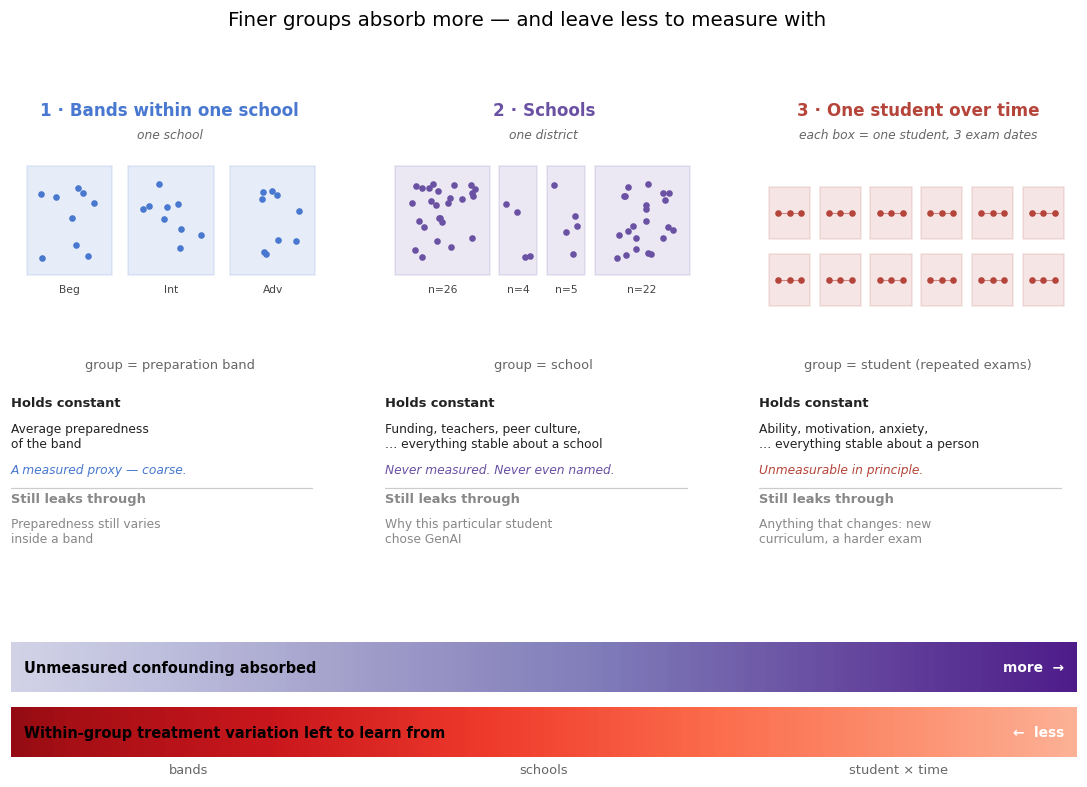

In [12]:
from matplotlib.patches import Rectangle

_r = np.random.default_rng(0)   # local: keeps the main simulation stream untouched

fig = plt.figure(figsize=(12.5, 7.8))
gs = fig.add_gridspec(2, 3, height_ratios=[3.4, 1], hspace=0.30, wspace=0.18)

LEVELS = [
    dict(
        title="1 · Bands within one school",
        subtitle="group = preparation band",
        holds="Average preparedness\nof the band",
        kind="A measured proxy — coarse.",
        leaks="Preparedness still varies\ninside a band",
        color="#4878CF",
    ),
    dict(
        title="2 · Schools",
        subtitle="group = school",
        holds="Funding, teachers, peer culture,\n… everything stable about a school",
        kind="Never measured. Never even named.",
        leaks="Why this particular student\nchose GenAI",
        color="#6A51A3",
    ),
    dict(
        title="3 · One student over time",
        subtitle="group = student (repeated exams)",
        holds="Ability, motivation, anxiety,\n… everything stable about a person",
        kind="Unmeasurable in principle.",
        leaks="Anything that changes: new\ncurriculum, a harder exam",
        color="#B5453A",
    ),
]


def _box(ax, x0, y0, w, h, color, label, dots=None, times=False):
    ax.add_patch(Rectangle((x0, y0), w, h, facecolor=color, alpha=.13,
                           edgecolor=color, lw=1.1, zorder=1))
    if times:
        xs = np.linspace(x0 + .22 * w, x0 + .78 * w, 3)
        ys = np.full(3, y0 + h / 2)
        ax.plot(xs, ys, color=color, lw=.7, alpha=.6, zorder=2)
    else:
        xs = _r.uniform(x0 + .15 * w, x0 + .85 * w, dots)
        ys = _r.uniform(y0 + .15 * h, y0 + .85 * h, dots)
    ax.scatter(xs, ys, s=11, color=color, zorder=3)
    ax.text(x0 + w / 2, y0 - .035, label, ha="center", va="top", fontsize=7, color="#444")


# --- top row: the three grouping units -------------------------------------
for j, lv in enumerate(LEVELS):
    ax = fig.add_subplot(gs[0, j])
    ax.set_xlim(0, 1); ax.set_ylim(-0.66, 1.06); ax.axis("off")
    c = lv["color"]

    if j == 0:      # three bands, one school
        for i, nm in enumerate(["Beg", "Int", "Adv"]):
            _box(ax, .05 + i * .32, .40, .27, .42, c, nm, dots=9)
        ax.text(.5, .93, "one school", ha="center", fontsize=8, style="italic", color="#666")
    elif j == 1:    # schools of very unequal size
        for x0, w_, n_ in [(.03, .30, 26), (.36, .12, 4), (.51, .12, 5), (.66, .30, 22)]:
            _box(ax, x0, .40, w_, .42, c, f"n={n_}", dots=n_)
        ax.text(.5, .93, "one district", ha="center", fontsize=8, style="italic", color="#666")
    else:           # many students, few observations each
        for row_y in (.54, .28):
            for i in range(6):
                _box(ax, .03 + i * .16, row_y, .13, .20, c, "", times=True)
        ax.text(.5, .93, "each box = one student, 3 exam dates",
                ha="center", fontsize=8, style="italic", color="#666")

    ax.text(.5, 1.02, lv["title"], ha="center", fontsize=11, weight="bold", color=c)
    ax.text(.5, .04, lv["subtitle"], ha="center", fontsize=8.5, color="#666")

    ax.text(0, -.11, "Holds constant", fontsize=8.5, weight="bold", color="#222")
    ax.text(0, -.17, lv["holds"], fontsize=8, va="top", color="#222")
    ax.text(0, -.33, lv["kind"], fontsize=8, style="italic", color=c, va="top")

    ax.plot([0, .95], [-.425, -.425], color="#CCC", lw=.8)
    ax.text(0, -.48, "Still leaks through", fontsize=8.5, weight="bold", color="#888")
    ax.text(0, -.54, lv["leaks"], fontsize=8, va="top", color="#888")

# --- bottom row: the trade-off ---------------------------------------------
axb = fig.add_subplot(gs[1, :])
axb.set_xlim(0, 1); axb.set_ylim(0, 1); axb.axis("off")

grad = np.linspace(0, 1, 256).reshape(1, -1)
axb.imshow(grad, extent=[0, 1, .56, .94], aspect="auto", cmap="Purples", vmin=-.45, vmax=1.15)
axb.imshow(grad[:, ::-1], extent=[0, 1, .06, .44], aspect="auto", cmap="Reds", vmin=-.45, vmax=1.15)

axb.text(.012, .75, "Unmeasured confounding absorbed", va="center", fontsize=9.5, weight="bold")
axb.text(.988, .75, "more  →", va="center", ha="right", fontsize=9, color="white", weight="bold")
axb.text(.012, .25, "Within-group treatment variation left to learn from",
         va="center", fontsize=9.5, weight="bold")
axb.text(.988, .25, "←  less", va="center", ha="right", fontsize=9, color="white", weight="bold")

for x, lab in [(1 / 6, "bands"), (.5, "schools"), (5 / 6, "student × time")]:
    axb.text(x, -.06, lab, ha="center", fontsize=8.5, color="#666")

fig.suptitle("Finer groups absorb more — and leave less to measure with",
             fontsize=13, y=0.99)
plt.show()

## Result Interpretation — Cell 12

### What did we actually get?

A schematic figure with three grouping units — bands (within a school), schools (within a district), and one student over time — plus a bottom bar showing absorbed unmeasured confounding (purple) growing while usable within-group treatment variation (red) shrinks.

### What does this result mean?

Fixed effects do not require observing a confounder — they require a group within which the confounder does not vary. The finer the group, the more confounding is absorbed but the less data is left to learn from: with student-level fixed effects, only students who switched GenAI behavior between exams would contribute.

### How should I interpret the numbers?

There are no numbers — the figure is illustrative, not data. The purple/red bars encode a qualitative trade-off, not measured quantities.

### What does this tell us?

Choosing the grouping unit is a bias–variance trade-off, and it explains the notebook's progression from bands to schools — and why student-level fixed effects are the last resort.

### What can we conclude?

The choice of grouping unit determines how much unmeasured confounding you remove versus how much variation remains for estimation.

### What can we NOT conclude?

The panel contains no data and no estimates, so nothing here should be read as a numerical result about GenAI or exam scores.

### Why does this result matter?

It frames the whole fixed-effects story conceptually before the matching comparison that follows.

### What should we do next?

Section 6 takes a natural detour: "Why not just match?" The next cell implements naive within-school matching and compares it with fixed effects.


**Read the two bars together — they are the whole trade-off.**

Moving right, each grouping unit is stricter about what it holds constant, so it absorbs more of the
confounding we could never have measured. Student fixed effects are the extreme: whatever makes *you*
you is differenced away entirely, and you are compared only against yourself.

But the same move starves the estimator. Bands gave us 100 students across 3 groups; schools gave us
some groups with only 4 students, and one with no treatment variation at all, which dropped out.
Push all the way to one student per group and you need that student to have **both** used and not used
GenAI across exams — otherwise, by Discussion 3.2, they contribute nothing.

**Discussion 4.5.** With student fixed effects and only two exam sittings per student, who is left in
the sample? Is that group representative of anyone we care about?

<details><summary>Expand</summary>

Only students who *switched* — used GenAI for one sitting and not the other. Everyone with a
consistent habit contributes nothing. The estimate is identified entirely off switchers, who may
differ systematically from steady users and steady abstainers. Absorbing more confounding narrowed
the question being answered. That is the cost, and it is rarely printed in the output.
</details>

---
## 6. "Why not just match?"

A natural objection:

> We already know each student's school. Why bother with fixed effects? Just find GenAI users and
> non-users *inside the same school*, take the difference, and average those differences.

This is a completely reasonable proposal, and it is **not wrong**. Let us actually do it.

## Cell 13 — Naive matching: average within-school differences equally

### Why are we doing this?

Section 6 asks a fair question: we know the school, so why not just compare users to non-users *inside* each school and average those differences? Matching is a reasonable-sounding alternative to fixed effects — this cell implements it so we can compare them honestly.

### What are we doing?

We define `matching_estimate(df, group_col)`: for each school with both user types, compute the within-school mean difference (users − non-users), then average those differences *unweighted* across schools. We print the estimate alongside the school FE estimate and the truth.

### How does it work?

- The loop skips schools where `genai.nunique() < 2` (no within-school variation).
- For usable schools it computes `mean(score | genai=1) − mean(score | genai=0)`.
- `np.mean(diffs)` treats every school equally — a 4-student school counts as much as a 250-student school.

### Why did we choose this approach?

Equal weighting is the natural naive implementation and the foil for fixed effects' variance weighting. It isolates the *weighting* as the only difference (the comparison itself is identical).

### Alternatives

- Student-level nearest-neighbor matching (as in last week's notebook) would be more elaborate but still raises the same weighting question at the aggregate level.

### Key Data Science Concepts

- **Within-group matching**: same comparison FE makes, different aggregation.
- **Unweighted vs. weighted averaging**: the hidden choice that changes the answer.

### Potential Issues / Improvements

- Equal weighting lets tiny schools dominate the average — the per-school SD (≈ 6.1) shows how noisy that is.
- Schools with no within-school treatment variation are skipped (1 of 30 here).
- Only the school grouping is used to form comparisons; no student-level covariates are matched on.

### What should we expect to examine after execution?

This cell prints the matching estimate and per-school difference statistics. After execution we will compare matching with the FE estimate and the truth.


In [13]:
def matching_estimate(df, group_col="school_id"):
    """Naive within-group matching: unweighted mean of within-school differences."""
    diffs, used = [], []
    for g, sub in df.groupby(group_col):
        if sub["genai"].nunique() < 2:
            continue
        diffs.append(sub.loc[sub.genai == 1, "score"].mean()
                     - sub.loc[sub.genai == 0, "score"].mean())
        used.append(g)
    if not diffs:
        return np.nan, 0, []
    return float(np.mean(diffs)), len(diffs), diffs


match_est, n_matchable, per_school = matching_estimate(district)

print(f"Matchable schools : {n_matchable} of {N_SCHOOLS}")
print(f"Per-school differences range from {min(per_school):+.1f} to {max(per_school):+.1f}")
print(f"  (standard deviation across schools: {np.std(per_school, ddof=1):.1f})")
print()
print(f"Matching estimate : {match_est:+.2f}")
print(f"School FE         : {fe_est:+.2f}")
print(f"True effect       : {TRUE_EFFECT:+.1f}")

Matchable schools : 29 of 30
Per-school differences range from -17.8 to +11.1
  (standard deviation across schools: 6.1)

Matching estimate : -4.02
School FE         : -4.92
True effect       : -5.0


## Result Interpretation — Cell 13

### What did we actually get?

Matchable schools: 29 of 30. Per-school differences range **−17.8 to +11.1** (SD ≈ 6.1). Matching estimate: **−4.02**; school FE: **−4.92**; true: **−5.0**.

### What does this result mean?

Both estimators land in the right neighborhood — matching is not *biased* here. The interesting difference is not direction but **variance**: the per-school differences spread over ~29 points (SD ≈ 6.1), with small schools dominating the extremes.

### How should I interpret the numbers?

Differences are in exam points. The range −17.8 to +11.1 spans ~29 points with SD ≈ 6.1, far wider than the FE estimate's spread. References: true −5.0, FE −4.92, matching −4.02.

### What does this tell us?

Both estimators recover the sign and rough magnitude of the effect; the difference between them is variance, not bias.

### What can we conclude?

Matching and FE both recover the sign and rough magnitude of the effect.

### What can we NOT conclude?

We cannot yet say which is better — the per-school spread hints that equal weighting may be noisier, but we need the bootstrap to quantify it.

### Why does this result matter?

It sets up the matching-vs-FE variance question that the rest of the notebook answers.

### What should we do next?

The next cell proves the key claim: FE is the same within-school comparison, weighted by `n·p(1−p)` — verifying that fixed effects *is* matching with derived weights.


Both are in the right neighbourhood. Neither is obviously broken. So **matching is not biased here** —
the interesting question is not *bias*, it is **variance**: how much would each estimate move if the
district had sent us a different set of schools?

Look at the spread of those per-school differencesbefore reading on.

### The hidden difference: weighting

Matching gave every school **one vote**. A school with 4 students counted exactly as much as a school
with 250. Is that sensible? A 4-student difference is nearly pure noise; a 250-student difference is
solid evidence.

It turns out fixed effects is doing the *same comparison*, but weighting each school by how much
treatment variation it actually carries:

$$\hat a_{\text{FE}} = \frac{\sum_s w_s D_s}{\sum_s w_s},
\qquad w_s = n_s\,p_s(1-p_s)$$

where $D_s$ is school $s$'s within-school difference, $n_s$ its size, and $p_s$ its share of GenAI
users. Let us verify that claim numerically.

## Cell 14 — Verify that fixed effects = variance-weighted matching

### Why are we doing this?

The markdown claims that the FE estimate equals a variance-weighted average of the same within-school differences, with weights `w_s = n_s · p_s · (1 − p_s)`. We verify that claim numerically — if true, it reframes FE as "matching done well."

### What are we doing?

For every school with both user types we compute `n` (size), `p` (share of GenAI users), weight `w = n·p·(1−p)`, and the within-school difference `D`. Then we compute the weighted average `Σ(w·D)/Σw` and compare it with the FE estimate.

### How does it work?

- `w = n_s · p_s · (1 − p_s)` is the variance of a Bernoulli share scaled by group size — a school contributes weight proportional to the treatment variation it actually carries.
- `weighted_match = (wdf.w * wdf.D).sum() / wdf.w.sum()` is the standard weighted mean formula.
- `np.isclose(weighted_match, fe_est)` checks equality within floating-point tolerance.

### Why did we choose this approach?

Direct computation is the most convincing proof of the equality. It also makes the "hidden weighting" of FE explicit so novices can see what is inside the black box.

### Alternatives

- An analytic derivation (Frisch–Waugh style) would prove it generally but is harder to grasp quickly.

### Key Data Science Concepts

- **Weighted mean**: `Σ w·D / Σ w`.
- **Weight = treatment variation**: `p(1−p)` peaks at p = 0.5 and shrinks toward homogeneous schools; `n` rewards larger schools.
- **FE as weighted matching**: the identical comparison, aggregated optimally.

### Potential Issues / Improvements

- The formula is exact here because the data are balanced; with covariates or weights it would be an approximation.

### What should we expect to examine after execution?

This cell prints the variance-weighted average, the FE estimate, and an "Identical?" check. After execution we will confirm whether FE equals weighted matching.


In [14]:
rows = []
for g, sub in district.groupby("school_id"):
    if sub["genai"].nunique() < 2:
        continue
    n_s = len(sub)
    p_s = sub["genai"].mean()
    rows.append({
        "school": g,
        "n": n_s,
        "p": p_s,
        "w": n_s * p_s * (1 - p_s),
        "D": sub.loc[sub.genai == 1, "score"].mean() - sub.loc[sub.genai == 0, "score"].mean(),
    })

wdf = pd.DataFrame(rows)
weighted_match = (wdf.w * wdf.D).sum() / wdf.w.sum()

print(f"Variance-weighted average of within-school differences : {weighted_match:+.4f}")
print(f"School fixed-effects estimate                          : {fe_est:+.4f}")
print(f"Identical?                                             : {np.isclose(weighted_match, fe_est)}")

Variance-weighted average of within-school differences : -4.9190
School fixed-effects estimate                          : -4.9190
Identical?                                             : True


## Result Interpretation — Cell 14

### What did we actually get?

Variance-weighted average: **−4.9190**; school FE estimate: **−4.9190**; "Identical? **True**."

### What does this result mean?

Fixed effects is not doing a different comparison than matching — it is the same within-school comparison, weighted by each school's treatment variation, `w = n·p·(1−p)`.

### How should I interpret the numbers?

Both values equal −4.9190 to machine precision. Reference: naive matching (Cell 13) gave −4.02 because small, noisy schools pulled the unweighted average.

### What does this tell us?

Fixed effects is the same comparison with data-driven weights.

### What can we conclude?

School FE ≈ weighted within-school matching (both ≈ −4.92), while naive matching (Cell 13) gave −4.02 because small, noisy schools pulled the average.

### What can we NOT conclude?

We cannot conclude FE is "smarter"; the next sections show its advantage is *precision*, which we still need to measure.

### Why does this result matter?

It exposes the mechanism behind fixed effects' efficiency: optimal weighting of the same within-group comparisons.

### What should we do next?

Now we turn to uncertainty: Section 7 introduces the bootstrap, first with one visible resample (Cell 15).


**Fixed effects *is* matching — with the right weights, derived automatically.**

This reframes the whole comparison. FE does not make a cleverer comparison than matching; it makes
the identical comparison and then aggregates it well. And the aggregation matters enormously here:

---
## 7. Bootstrapping, part 1: measuring an estimator's stability

We have one sample of 30 schools. We cannot rerun the district. But we can ask a surrogate question:

> What if we drew 30 schools **from the schools we already have**, with replacement?

The empirical sample stands in for the unknown population. This approximates repeated sampling —
it does **not** manufacture new independent evidence, and it cannot tell us whether our 30 schools
were representative in the first place.

### Three objects to keep distinct

| Object | What it is |
|--------|-----------|
| Population truth | $a = -5$ — known only because we simulated it |
| Our estimate $\hat a$ | One number, from the 30 observed schools |
| Bootstrap estimates $\hat a^*_b$ | Many numbers, from resampled schools |

### One resample, made visible

We resample **schools**, not rows. A selected school arrives with its **complete roster**, and each
draw gets a fresh identity so that two copies of the same school are treated as two separate schools
when we demean.

## Cell 15 — One bootstrap resample, made visible

### Why are we doing this?

Before running hundreds of bootstrap replicates, we want to see what a single resample looks like. This builds intuition for "resample the schools, not the rows."

### What are we doing?

We draw 30 schools **with replacement** from the 30 observed school ids using a fresh RNG, count how many schools appear once, more than once, or not at all, and print those counts.

### How does it work?

- `all_schools = district["school_id"].unique()` — the 30 school identities.
- `np.random.default_rng(7).choice(all_schools, size=len(all_schools), replace=True)` — a bootstrap draw: same size, with replacement.
- `pd.Series(demo_draw).value_counts()` counts how often each school was drawn.

### Why did we choose this approach?

Sampling with replacement is the heart of the bootstrap: some schools repeat, others vanish, and the resample is a new "pseudo-district" of the same size.

### Alternatives

- Sampling without replacement would just reshuffle — no bootstrap information gain.

### Key Data Science Concepts

- **Bootstrap resampling**: draw with replacement from the empirical distribution.
- **Resample at the sampled unit**: schools are the unit, so whole school rosters travel together (cluster bootstrap) — never individual students, because students within a school are dependent.

### Potential Issues / Improvements

- One resample is illustrative only; conclusions about variability require many replicates.
- The RNG seed (7) pins the exact counts; other seeds give different counts for the same data.
- Bootstrap draws with replacement re-weight the observed schools; they do not create new schools.

### What should we expect to examine after execution?

This cell prints counts from one bootstrap resample. After execution we will see how many schools were drawn once, more than once, or not at all.


In [15]:
all_schools = district["school_id"].unique()
demo_draw = np.random.default_rng(7).choice(all_schools, size=len(all_schools), replace=True)

counts = pd.Series(demo_draw).value_counts()
print(f"Original schools : {len(all_schools)}")
print(f"Distinct schools in this draw : {counts.size}")
print(f"Schools drawn more than once  : {(counts > 1).sum()}")
print(f"Schools not drawn at all      : {len(all_schools) - counts.size}")

Original schools : 30
Distinct schools in this draw : 22
Schools drawn more than once  : 7
Schools not drawn at all      : 8


## Result Interpretation — Cell 15

### What did we actually get?

Original schools: 30. Distinct in this draw: 22. Drawn more than once: 7. Not drawn at all: 8.

### What does this result mean?

A single bootstrap draw with replacement loses 8 of the 30 schools and duplicates 7 others. That variation across draws is exactly what generates spread in bootstrap estimates.

### How should I interpret the numbers?

The counts are school identities. Of 22 distinct schools drawn, 7 appear more than once (15 appear once); 30 − 22 = 8 schools never appear in this draw.

### What does this tell us?

The bootstrap deliberately varies the school set; each replicate is a different 30-school pseudo-sample.

### What can we conclude?

The bootstrap varies the school set by design — resampling with replacement is the engine of the method.

### What can we NOT conclude?

One draw says nothing about the estimator's variability — the whole point is to repeat this many times.

### Why does this result matter?

It builds intuition for why cluster resampling can produce spread across replicates.

### What should we do next?

The next cell runs B = 600 such draws and recomputes both FE and matching on each — the real bootstrap.


**Why resample schools rather than individual students?** Students in a school share a baseline
$\alpha_s$, so their outcomes are dependent. Resampling rows independently would shatter that
structure and understate the uncertainty. Note this "cluster bootstrap" means *resampling school
bundles* — it has nothing to do with clustering algorithms.

## Cell 16 — Run the cluster bootstrap for both estimators

### Why are we doing this?

This is the real bootstrap: quantify how much the FE and matching estimates would move if the district sent a different set of 30 schools. We resample whole schools (cluster bootstrap) 600 times and recompute both estimators on every replicate.

### What are we doing?

We define `boot_both(df, B, seed, group_col)` that draws 30 schools with replacement, rebuilds a pseudo-district with fresh group ids (`_bid`), recomputes the FE coefficient and the matching estimate, and records them. We run it with B = 600 and print how many replicates were non-identifiable for each estimator.

### How does it work?

- `r.choice(groups, size=len(groups), replace=True)` — a bootstrap school draw.
- Each drawn school's rows get `_bid = f"{g}#{k}"`: duplicate schools become distinct groups, so the demean step treats them separately.
- `fe_coeff(db, "_bid")` and `matching_estimate(db, "_bid")` reuse the estimators defined earlier; `np.isnan` counts failures (e.g., a draw where no school has both user types).
- 600 replicates is chosen for a stable standard deviation without excessive runtime.

### Why did we choose this approach?

Resampling at the school level preserves the within-school dependence (cluster bootstrap). Reusing the existing estimator functions keeps the code short and the logic identical to the observed-data analysis.

### Alternatives

- Resampling rows would break school structure and understate uncertainty — explicitly warned against here.
- More replicates (e.g., 10,000) would stabilize the standard error further at higher compute cost; 600 is a compromise.

### Key Data Science Concepts

- **Cluster bootstrap**: the resampling unit is the cluster (school), not the row.
- **Non-identifiable replicates**: bootstrap draws can lack treatment variation inside groups; those yields NaN and must be tracked (not silently averaged).

### Potential Issues / Improvements

- A resample can by chance contain no usable school; both estimators then return NaN — the counters tell us it did not happen here (0 failures each).
- The RNG seeds (`99`) make the bootstrap reproducible.

### What should we expect to examine after execution?

This cell prints replicate counts (600 draws) and failure counts. After execution we will check that both estimators succeeded on every replicate.


In [16]:
def boot_both(df, B, seed, group_col="school_id"):
    """Resample schools with replacement; recompute BOTH estimators on each resample."""
    r = np.random.default_rng(seed)
    groups = df[group_col].unique()
    fe_out, mt_out, fe_bad, mt_bad = [], [], 0, 0

    for _ in range(B):
        draw = r.choice(groups, size=len(groups), replace=True)
        parts = []
        for k, g in enumerate(draw):
            sub = df[df[group_col] == g].copy()
            sub["_bid"] = f"{g}#{k}"          # unique id per draw
            parts.append(sub)
        db = pd.concat(parts, ignore_index=True)

        c, _, _, _ = fe_coeff(db, "_bid")
        if np.isnan(c):
            fe_bad += 1
        else:
            fe_out.append(c)

        m, _, _ = matching_estimate(db, "_bid")
        if np.isnan(m):
            mt_bad += 1
        else:
            mt_out.append(m)

    return np.array(fe_out), np.array(mt_out), fe_bad, mt_bad


B = 600
fe_boot, mt_boot, fe_bad, mt_bad = boot_both(district, B, seed=99)
print(f"B = {B} replicates.  Non-identifiable draws — FE: {fe_bad}, matching: {mt_bad}")

B = 600 replicates.  Non-identifiable draws — FE: 0, matching: 0


## Result Interpretation — Cell 16

### What did we actually get?

B = 600 replicates; non-identifiable draws — FE: 0, matching: 0.

### What does this result mean?

Every one of the 600 resamples produced both estimates; no draw was degenerate (for example, a resample that happened to contain no school with both user types).

### How should I interpret the numbers?

Counts are failed replicates out of 600. Zero failures means the coming distributions (Cells 17–18) are complete and clean.

### What does this tell us?

The bootstrap machinery works: 600 usable FE and 600 usable matching estimates.

### What can we conclude?

The bootstrap produced a complete set of replicates for both estimators.

### What can we NOT conclude?

We have not yet looked at the spread — that is the next two cells.

### Why does this result matter?

It confirms the simulation ran cleanly before we interpret any distribution.

### What should we do next?

The next cell plots the two bootstrap distributions side by side, where the width difference becomes visible.


## Cell 17 — Histogram of the bootstrap distributions

### Why are we doing this?

We want to *see* the payoff: FE and matching target the same true effect, so both histograms should center near −5 — but their widths should differ. The plot is the visual summary of the whole matching-vs-FE story.

### What are we doing?

We draw overlapping histograms of the 600 bootstrap estimates from `fe_boot` and `mt_boot`, with the true effect marked as a dashed line and each distribution's bootstrap SD printed in its legend.

### How does it work?

- `np.linspace(min(...) − .3, max(...) + .3, 55)` builds shared bins so the two histograms are directly comparable on the same axis.
- `ax.hist(...)` overlays matching (red) and FE (blue) with partial transparency.
- `ax.axvline(TRUE_EFFECT, ls="--")` marks where the estimate should be.

### Why did we choose this approach?

Comparing two histograms on shared bins is the most honest way to show both bias (centers) and variance (widths) simultaneously.

### Alternatives

- Box plots or violin plots; histograms keep the actual shape visible.

### Key Data Science Concepts

- **Sampling distribution**: the spread of an estimator across resamples ≈ its uncertainty.
- **Bias vs. variance visually**: where the histogram centers vs. how wide it is.

### Potential Issues / Improvements

- The SDs are bootstrap approximations based on B = 600; more replicates would stabilize them further.
- Histogram bin choice can slightly change the visual impression of the two distributions.
- Both estimators share the same 600 school draws, so the two distributions are correlated rather than independent.

### What should we expect to examine after execution?

This cell draws overlapping histograms of the 600 bootstrap estimates. After execution we will compare the centers and widths of the two distributions.


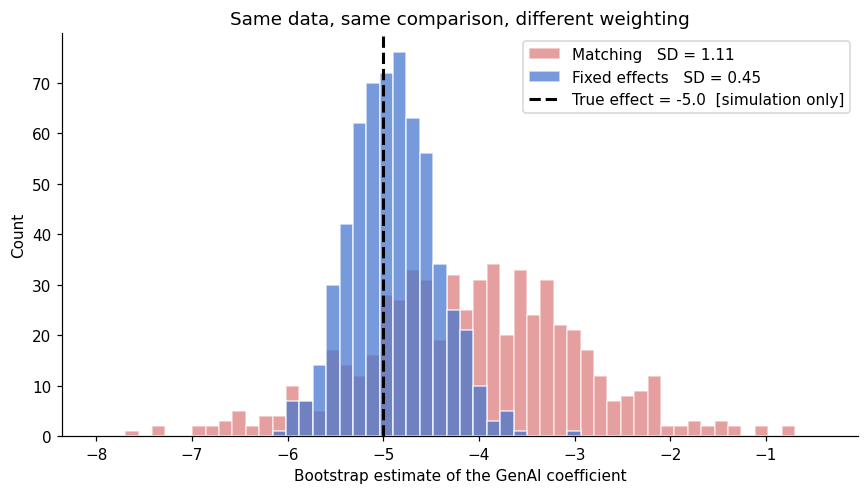

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.6))
bins = np.linspace(min(mt_boot.min(), fe_boot.min()) - .3,
                   max(mt_boot.max(), fe_boot.max()) + .3, 55)

ax.hist(mt_boot, bins=bins, alpha=.6, color="#D65F5F", edgecolor="white",
        label=f"Matching   SD = {mt_boot.std(ddof=1):.2f}")
ax.hist(fe_boot, bins=bins, alpha=.75, color="#4878CF", edgecolor="white",
        label=f"Fixed effects   SD = {fe_boot.std(ddof=1):.2f}")
ax.axvline(TRUE_EFFECT, color="black", ls="--", lw=2,
           label=f"True effect = {TRUE_EFFECT:+.1f}  [simulation only]")

ax.set_xlabel("Bootstrap estimate of the GenAI coefficient")
ax.set_ylabel("Count")
ax.set_title("Same data, same comparison, different weighting")
ax.legend()
plt.tight_layout()
plt.show()

## Result Interpretation — Cell 17

### What did we actually get?

Two overlapping histograms, both centered near the dashed line at −5: matching is visibly **wider** (SD ≈ 1.11) than fixed effects (SD ≈ 0.45).

### What does this result mean?

Neither estimator has a meaningful bias problem — both distributions center on the truth. The difference is pure variance: equal-weight matching scatters roughly 2.5× more than FE.

### How should I interpret the numbers?

The SDs (1.11 vs. 0.45) are the standard deviations of the 600 bootstrap estimates — i.e., each estimator's uncertainty. The reference line is the true effect, −5, where both histograms peak.

### What does this tell us?

Neither estimator has a meaningful bias problem here; the difference is pure variance.

### What can we conclude?

On identical data, fixed effects produce a much tighter (more precise) estimate than equal-weight matching.

### What can we NOT conclude?

The histograms are bootstrap approximations; they do not reveal anything about whether our 30 schools are representative of the district.

### Why does this result matter?

It is the visual proof that the weighting choice — not the comparison — drives the precision gain.

### What should we do next?

The next cell adds the numbers: bootstrap means, SDs, percentiles, and interval widths in a table.


## Cell 18 — Bootstrap summary table and interval widths

### Why are we doing this?

The histograms showed the story; this cell prints it as numbers: bootstrap mean, bootstrap standard deviation, and 2.5% / 97.5% percentiles for each estimator, plus the interval width and the width ratio.

### What are we doing?

We build a small DataFrame with one row per estimator, compute the percentiles and the CI width, print it, and print how many times more variable matching is than FE.

### How does it work?

- `fe_boot.std(ddof=1)` — sample standard deviation of the 600 bootstrap FE estimates (the bootstrap standard error).
- `np.percentile(x, 2.5)` and `np.percentile(x, 97.5)` — the percentile interval endpoints (a simple bootstrap CI).
- `CI width = 97.5% − 2.5%`, and the ratio `mt_boot.std / fe_boot.std` quantifies the precision gap.

### Why did we choose this approach?

Percentile intervals are the most transparent bootstrap interval; the table format makes the two lines directly comparable.

### Alternatives

- Normal-approximation intervals (±1.96·SE) or bias-corrected intervals (BCa); percentile is fine for exposition.

### Key Data Science Concepts

- **Bootstrap SD = standard error**: the SD of resample estimates estimates the sampling variability of the original estimate.
- **Percentile confidence interval**: an interval from the 2.5th to 97.5th percentiles — an approximation with finite-sample caveats, not a probability statement about the fixed true effect.

### Potential Issues / Improvements

- The percentile interval is a simple bootstrap interval; BCa or normal-approximation intervals could differ slightly.
- With B = 600, the 2.5/97.5 quantiles are approximate and would jitter with more replicates.
- The table describes the bootstrap of our observed district; it says nothing about whether the 30 schools represent the district.

### What should we expect to examine after execution?

This cell prints a summary table of bootstrap means, SDs, percentiles, and CI widths. After execution we will compare the precision of FE vs. matching.


In [18]:
summary_boot = pd.DataFrame({
    "Estimator": ["Fixed effects", "Matching (equal weights)"],
    "Bootstrap mean": [fe_boot.mean(), mt_boot.mean()],
    "Bootstrap SD": [fe_boot.std(ddof=1), mt_boot.std(ddof=1)],
    "2.5%": [np.percentile(fe_boot, 2.5), np.percentile(mt_boot, 2.5)],
    "97.5%": [np.percentile(fe_boot, 97.5), np.percentile(mt_boot, 97.5)],
})
summary_boot["CI width"] = summary_boot["97.5%"] - summary_boot["2.5%"]
print(summary_boot.round(2).to_string(index=False))
print(f"\nMatching is {mt_boot.std(ddof=1) / fe_boot.std(ddof=1):.2f}x more variable than fixed effects.")

               Estimator  Bootstrap mean  Bootstrap SD  2.5%  97.5%  CI width
           Fixed effects           -4.90          0.45 -5.71  -4.03      1.68
Matching (equal weights)           -4.08          1.11 -6.38  -1.90      4.49

Matching is 2.50x more variable than fixed effects.


## Result Interpretation — Cell 18

### What did we actually get?

Fixed effects: bootstrap mean −4.90, SD 0.45, 2.5% −5.71, 97.5% −4.03, CI width 1.68. Matching (equal weights): mean −4.08, SD 1.11, 2.5% −6.38, 97.5% −1.90, CI width 4.49. Matching is **2.50× more variable** than fixed effects.

### What does this result mean?

Both methods are roughly unbiased, but FE is far more precise on identical data: its percentile interval is ~2.7× narrower, and both intervals contain the true −5.

### How should I interpret the numbers?

The SDs are bootstrap standard errors in exam points. CI widths of 1.68 vs. 4.49 shrink the practical interval by ~2.7×. The 2.50 ratio is the variability multiplier of matching relative to FE.

### What does this tell us?

Both methods are roughly unbiased, but FE is far more precise on identical data.

### What can we conclude?

Choosing the right weights buys real precision — for free, from data we already had: the CI width shrinks from ~4.5 to ~1.7 points.

### What can we NOT conclude?

The percentile interval is an approximation; it does not mean the truth lies inside with 95% probability, and it says nothing about representativeness of the 30 schools.

### Why does this result matter?

It quantifies the headline result of the matching-vs-FE section: weighting changes precision by 2.5×.

### What should we do next?

The optional markdown formalizes the bootstrap SE formula; the next cell compares the bootstrap SE with the OLS analytical SE.


**This is the payoff.** Both estimators target the same quantity and neither is meaningfully biased,
but on identical data the matching interval is roughly **two and a half times wider**. Choosing the
estimator with the right weights buys real precision — for free, from data we already had.

### Reading the bootstrap standard error (Optional)

$$\widehat{SE}_{\mathrm{boot}}(\hat a) = \sqrt{\frac{1}{B-1}\sum_{b=1}^{B}\left(\hat a^*_b - \bar a^*\right)^2}$$

**The standard deviation of the bootstrap estimates estimates the standard error of our original
estimator.** It is *not* the standard deviation of individual exam scores.

Do **not** divide it by $\sqrt{B}$ — that answers a different question (how precisely we have pinned
down the bootstrap mean). More replicates $B$ stabilise the approximation; only more *genuinely
observed schools* improve the underlying precision.

## Cell 19 — Bootstrap SE vs. OLS analytical SE

### Why are we doing this?

We have two ways to quantify the FE coefficient's uncertainty: the bootstrap standard error (from Section 7) and the analytical standard error that statsmodels printed back in Cell 11 (`fe_se`). Comparing them checks whether the model-based formula is trustworthy here.

### What are we doing?

We print the bootstrap SE of the FE distribution, the OLS analytical SE saved from `fe_coeff`, and the approximate 95% percentile interval.

### How does it work?

- `fe_boot.std(ddof=1)` — the bootstrap SE (standard deviation of the 600 replicate estimates).
- `fe_se` — the `bse` returned by the OLS fit in Cell 11, derived under the model's error assumptions.
- The percentile interval uses the 2.5th and 97.5th percentiles of `fe_boot`.

### Why did we choose this approach?

Contrasting the two numbers makes the methodological lesson concrete: an analytical SE is cheap but rests on assumptions; the bootstrap asks a blunter, data-driven question.

### Alternatives

- Cluster-robust (sandwich) standard errors are the classical fix for school-level dependence; not computed here, but a natural third comparison.

### Key Data Science Concepts

- **Analytical vs. resampling inference**: formulas vs. computational re-sampling.
- **Cluster dependence**: the analytical `bse` assumes independent, equal-variance errors — violated when students share a school; the bootstrap honors the cluster structure by resampling schools.

### Potential Issues / Improvements

- The analytical SE assumes independent, equal-variance errors; the bootstrap does not rely on that assumption.
- The agreement between the two SEs here (0.446 vs. 0.533) is specific to these data, not a general rule.
- The percentile interval's coverage is approximate in finite samples such as this one.

### What should we expect to examine after execution?

This cell prints the bootstrap SE, the analytical SE, and the percentile interval. After execution we will compare the two SEs and check whether the interval covers the true effect.


In [19]:
print(f"Bootstrap SE for the FE coefficient : {fe_boot.std(ddof=1):.3f}")
print(f"OLS analytical SE (`bse`)           : {fe_se:.3f}")
print(f"Approximate 95% percentile interval : "
      f"[{np.percentile(fe_boot, 2.5):+.2f}, {np.percentile(fe_boot, 97.5):+.2f}]")

Bootstrap SE for the FE coefficient : 0.446
OLS analytical SE (`bse`)           : 0.533
Approximate 95% percentile interval : [-5.71, -4.03]


## Result Interpretation — Cell 19

### What did we actually get?

Bootstrap SE: **0.446**; OLS analytical SE: **0.533**; 95% percentile interval: **[−5.71, −4.03]**.

### What does this result mean?

The data-driven bootstrap and the model-based analytical standard errors agree to within ~0.09 (≈ 17%). That is reassuring: the clustered structure does not badly violate the analytical assumptions.

### How should I interpret the numbers?

Both SEs are in exam points. 0.446 vs. 0.533 differ by ~0.09; both are far smaller than the matching SE of 1.11. The interval [−5.71, −4.03] covers the true −5, which sits comfortably inside.

### What does this tell us?

For these data, the model-based standard error and the bootstrap agree; the clustered structure does not badly violate the analytical assumptions.

### What can we conclude?

The FE estimate −4.92 carries about ±0.45–0.53 points of sampling error, and the interval easily contains the true −5.

### What can we NOT conclude?

The interval is a finite-sample approximation; it is not a guarantee of coverage, and it says nothing about unmeasured within-school confounders.

### Why does this result matter?

It validates the cheap analytical SE against the heavier bootstrap — agreement means either is usable here.

### What should we do next?

Section 8 asks what more schools would buy us; the next cell simulates fresh districts of increasing size and watches the sampling distribution tighten.


The analytical standard error comes almost free from OLS, but it is derived under assumptions —
independent, equal-variance errors — that our clustered data do not obviously satisfy. The bootstrap
asks a blunter question: *resample the schools and look.* The two broadly agree here, which is
reassuring; when they disagree, that disagreement is itself information.

The percentile interval uses the 2.5th and 97.5th percentiles. Treat it as an approximation with
finite-sample caveats — not a promise of exact coverage, and not a claim that the fixed true effect
has a 95% probability of lying in this particular interval.

---
## 8. Bootstrapping, part 2: what would more schools buy us?

A fair follow-up: our interval is still a couple of points wide. Could the district simply send more
schools? Because this is a simulation, we can answer that directly — draw **fresh districts** of
increasing size and watch the sampling distribution tighten.

This is a different exercise from Section 7. There we resampled *our* schools to quantify the
uncertainty we actually face. Here we generate *new* schools to see what precision money could buy.

## Cell 20 — Simulate fresh districts: what more schools buy us

### Why are we doing this?

Our interval is still a couple of points wide. A fair follow-up: could the district simply send more schools? Because this is a simulation, we can answer directly — generate *new* districts of increasing size and watch the SD of the estimates shrink.

### What are we doing?

For 10, 30, 100, and 300 schools, we draw several fresh districts (`simulate_district`), compute both estimators on each, and collect the mean and SD of FE and matching estimates into a table.

### How does it work?

- `r = np.random.default_rng(1234 + n_s)` — a different seed per size, for reproducibility.
- `reps = 120 if n_s < 100 else 40` — more replicates for the cheaper small runs.
- Each replicate calls `simulate_district(n_s, r)`, then `fe_coeff` and `matching_estimate`; NaNs are skipped.
- The printed `growth` DataFrame holds mean/SD for both estimators at each size.

### Why did we choose this approach?

This is a *sampling-distribution simulation* — explicitly labelled as such in the markdown: it manufactures new outcomes from a known model as a teaching device. That is legitimate here only because we say so; it must never be done *inside* a bootstrap.

### Alternatives

- Deriving the convergence rate analytically; simulation is more intuition-friendly.

### Key Data Science Concepts

- **Consistency**: bias does not shrink with n, but variance does; both estimator means hover at −5 at every size.
- **Standard error ~ 1/√n**: quadrupling schools roughly halves the SD.

### Potential Issues / Improvements

- This is a simulation from the known DGP; real districts would draw from unknown processes.
- Fewer replicates at larger school counts (40 vs. 120) make the tail rows of the table noisier.
- The pattern (SD shrinking with more schools) is specific to this DGP's noise levels.

### What should we expect to examine after execution?

This cell prints the growth table of means and SDs across fresh districts. After execution we will see how precision improves with more schools for both estimators.


In [20]:
rows = []
for n_s in [10, 30, 100, 300]:
    r = np.random.default_rng(1234 + n_s)
    fe_list, mt_list = [], []
    reps = 120 if n_s < 100 else 40
    for _ in range(reps):
        d = simulate_district(n_s, r)
        c, _, _, _ = fe_coeff(d)
        m, _, _ = matching_estimate(d)
        if not np.isnan(c):
            fe_list.append(c)
        if not np.isnan(m):
            mt_list.append(m)
    rows.append({
        "Schools": n_s,
        "FE mean": np.mean(fe_list), "FE SD": np.std(fe_list, ddof=1),
        "Match mean": np.mean(mt_list), "Match SD": np.std(mt_list, ddof=1),
    })

growth = pd.DataFrame(rows)
print(growth.round(2).to_string(index=False))

 Schools  FE mean  FE SD  Match mean  Match SD
      10    -5.00   1.85       -4.75      3.00
      30    -4.98   0.79       -4.91      1.81
     100    -4.93   0.42       -4.67      0.85
     300    -4.99   0.19       -4.98      0.55


## Result Interpretation — Cell 20

### What did we actually get?

Schools 10/30/100/300 → FE mean −5.00/−4.98/−4.93/−4.99 with SD 1.85/0.79/0.42/0.19; matching mean −4.75/−4.91/−4.67/−4.98 with SD 3.00/1.81/0.85/0.55.

### What does this result mean?

Both estimators stay centered on −5 at every size (consistent: bias does not shrink with n, variance does), and FE is tighter at every size. Going from 10 to 300 schools shrinks FE's SD about 10×.

### How should I interpret the numbers?

The SDs are sampling distributions across fresh districts, in exam points. FE SD falls 1.85 → 0.19 and matching 3.00 → 0.55 as the school count grows 30×, roughly the 1/√n pattern.

### What does this tell us?

Additional schools buy precision for both estimators, and FE remains more precise at every size — matching's issue is variance, not bias.

### What can we conclude?

Precision is purchasable in principle — but the district cannot actually supply 300 schools.

### What can we NOT conclude?

This is a simulation of fresh draws, not of representativeness: it does not tell us whether our actual 30 schools look like the district.

### Why does this result matter?

It shows what the observed precision gap would cost to fix with more data — and that we cannot afford it.

### What should we do next?

The markdown after this cell draws the two readings (consistency; unpurchasable precision); the final section lists what remains unaddressed even by FE.


## Cell 21 — Visualize how precision improves with more schools

### Why are we doing this?

The growth table is easier to read as a picture: two curves (FE and matching) showing how the SD of the estimate falls as the number of schools rises, with a marker for how many schools we actually have.

### What are we doing?

We plot `growth["Schools"]` (log scale) against the FE SD (blue circles) and matching SD (red squares), add a vertical dotted line at `N_SCHOOLS = 30`, label it "what we actually have," and annotate axes and legend.

### How does it work?

- `ax.plot(growth["Schools"], growth["FE SD"], "o-", ...)` and `"s--"` — two series on shared axes.
- `ax.set_xscale("log")` spreads the 10/30/100/300 points evenly; the SD y-axis is the spread across fresh districts.
- `ax.axvline(N_SCHOOLS)` marks the real sample size; the text places awareness that we are at the left end of the curve.

### Why did we choose this approach?

Log-x makes the doubling structure visible, and the vertical line grounds the abstract simulation in the actual 30 schools.

### Alternatives

- A log–log plot (both axes log) would show the −½ slope of a rate-constancy law; unnecessary here.

### Key Data Science Concepts

- **Standard error decay with sample size**: estimates tighten roughly like 1/√n.
- **Reading the gap between curves**: FE is uniformly tighter, and the gap roughly persists at every size.

### Potential Issues / Improvements

- The SD curves come from fresh simulated districts, not from our single observed district — they show what *could* happen, not what our data will do.
- The flattened curves show diminishing returns: beyond some size, extra schools buy little precision.
- The dashed line at 30 schools anchors the discussion, but our actual sample is one draw at that size.

### What should we expect to examine after execution?

This cell draws the precision-vs-schools chart. After execution we will read how the two SD curves fall with more schools and where our real sample (30 schools) sits.


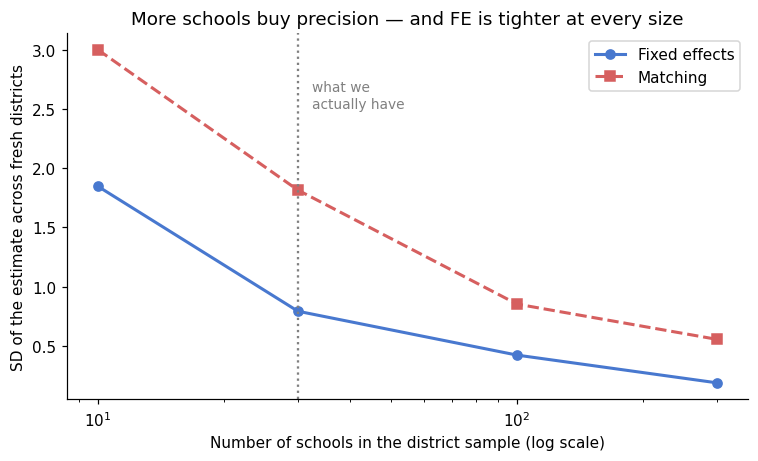

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(growth["Schools"], growth["FE SD"], "o-", color="#4878CF", lw=2, label="Fixed effects")
ax.plot(growth["Schools"], growth["Match SD"], "s--", color="#D65F5F", lw=2, label="Matching")
ax.axvline(N_SCHOOLS, color="grey", ls=":", lw=1.5)
ax.text(N_SCHOOLS * 1.08, ax.get_ylim()[1] * .8, "what we\nactually have", fontsize=9, color="grey")
ax.set_xscale("log")
ax.set_xlabel("Number of schools in the district sample (log scale)")
ax.set_ylabel("SD of the estimate across fresh districts")
ax.set_title("More schools buy precision — and FE is tighter at every size")
ax.legend()
plt.tight_layout()
plt.show()

## Result Interpretation — Cell 21

### What did we actually get?

Two declining curves — FE (blue circles) and matching (red squares) — over 10–300 schools on a log-x axis. The matching line stays above FE everywhere; a dashed vertical line at 30 schools (N_SCHOOLS) marks what we actually have (FE SD ≈ 0.79, matching SD ≈ 1.81).

### What does this result mean?

Precision is purchasable — more schools shrink both SDs — and FE is more efficient at every scale. At our real sample size (30 schools), matching is ~2.3× as variable as FE.

### How should I interpret the numbers?

The y-axis SDs are in exam points. At 30 schools, FE ≈ 0.79 vs. matching ≈ 1.81. Both curves descend steeply then flatten, showing diminishing returns from more schools.

### What does this tell us?

Precision improves with more schools for both estimators, with FE uniformly tighter.

### What can we conclude?

The honest move is to quantify the uncertainty we actually face (the Section 7 bootstrap) rather than to wish for more schools we cannot get.

### What can we NOT conclude?

This chart is a sampling-distribution simulation; it tells us nothing about the true effect or whether the real 30 schools are representative.

### Why does this result matter?

It gives the practical takeaway: report the uncertainty you have; do not chase data you cannot collect.

### What should we do next?

The closing markdown lists what FE still cannot address (within-school selection, time-varying confounders, representativeness) and summarizes the notebook's takeaways.


Two readings:

1. **Both estimators are consistent** — both means sit on $-5$ at every size, so matching's problem
   really is variance, not bias. FE is uniformly tighter.
2. **Precision is purchasable, but we cannot purchase it.** Reaching 300 schools would require the
   district to run a far larger release than the pilot allows.

That is exactly why Section 7 mattered. We cannot conjure more schools, so the honest move is to
quantify the uncertainty we *do* face — which is what the bootstrap did, using only the 30 schools
we were given.

> Note: this section is an explicitly labelled **simulation of the sampling distribution** — it
> generates new outcomes from the known model. That is a legitimate teaching device precisely because
> we labelled it. Never do this *inside* a bootstrap.

What remains unaddressed even in our FE estimate:

- **Within-school selection** — students choose GenAI for reasons that vary *inside* a school
  (motivation, anxiety, study habits). School FE cannot touch these.
- **Time-varying confounders** — a curriculum change or a harder exam moves with adoption over time.
  Fixed effects absorb what is *stable*; they are silent about what *changes*.
- **Representativeness** — 30 schools may simply not look like the district. No amount of resampling
  reveals that.

---
## 10. Takeaways

1. **Fixed effects account for stable group differences.** Give each group its own intercept, and
   compare only within groups. Indicators and demeaning are two equivalent routes to the same slope —
   the grouping unit decides whose average you subtract, and therefore which comparison you make.

2. **Fixed effects is matching, weighted correctly.** Both make the same within-group comparison. FE
   weights each group by the treatment variation it carries, which here produced an interval
   **2.5× narrower** on identical data.

3. **Bootstrapping quantifies sampling uncertainty.** Resample at the unit that was sampled — whole
   schools, complete rosters, fresh identities — and take the standard deviation of the resulting
   estimates.